<a href="https://colab.research.google.com/github/dariashcherbakovaaa/MA_DSE_Unimi/blob/Thesis/Classical_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/to_sent/')

! pip install bornrule
! pip install iterative-stratification

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import ast
from datapreprocessing import *
from my_func import *

nltk.download('all')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn import metrics

from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_fscore_support, roc_auc_score, hamming_loss
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import svm
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import MultinomialNB

from lightgbm import LGBMClassifier
from bornrule import BornClassifier

from sklearn.multioutput import ClassifierChain
from sklearn.metrics import jaccard_score

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_d

In [ ]:
df1 = pd.read_excel('/content/drive/MyDrive/to_sent/Verbatim_Maxidi - Mattia.xlsx').rename(columns={'D15' : 'text'}).drop(columns=['Unnamed: 18'])
df2 = pd.read_excel('/content/drive/MyDrive/to_sent/Verbatim_Suggerimenti_Superemme.xlsx').rename(columns={'Verbatim': 'text'})
df3 = pd.read_excel('/content/drive/MyDrive/to_sent/Cds_verbatim.xlsx').rename(columns={'D15':'text'})

df1 = df1.iloc[: , 1:]
df2 = df2.iloc[: , 1:]
df3 = df3.iloc[:,1:]

database = pd.concat([df1, df2, df3], ignore_index=True)

database['all_codes'] = database.iloc[:, 1:].apply(lambda x: '; '.join(x.dropna()), axis=1)
data = database[['text','all_codes']].copy()
data.columns = ['text', 'label']

data = data.drop_duplicates()
data.dropna(inplace = True)
print(f"The total database size: {data.shape}")
print(f"# unique answers: {data.text.nunique()}")
print(f"# unique labels: {data.label.nunique()}")

data.head()

The total database size: (2481, 2)
# unique answers: 2479
# unique labels: 740


,text,label
0,personale di servizio barriera casse,Casse; Personale
1,nella pulizia e nella professionalità dei resp...,Promozioni; Ordine&Pulizia; Personale
2,più varietà e scaffali ben riforniti quando ci...,Promozioni; Riapprovigionamento; Varietà
3,sicuramente la cortesia alle casse!!,Casse; Personale
4,prodotti freschi senza glutine,Gluten Free


# Data preprocessing

In [ ]:
%%time
prepr = DataPreprocessing(data)
data = prepr.normalisation_data()
data.label = data.label.astype(str).apply(lambda x: x.strip())
data = prepr.ita_translate()
data = prepr.clean_text()
data.text = data.text.apply(prepr.remove_tags)
data = prepr.lemmatisation_text('text')
data.label = data.label.apply(prepr.lemmatisation_label)
data = data[~data['text'].apply(prepr.trash)]
data = data[(data['text'] != "") & (data['label'] != "")]

idx_drop = data[data.label == 'zzz'].index
data.drop(idx_drop, inplace=True)

CPU times: user 7.78 s, sys: 219 ms, total: 8 s
Wall time: 8.22 s


In [ ]:
data_cleaned = data[['text', 'label']].copy()
data_cleaned = data_cleaned.drop_duplicates(ignore_index=True)

data_cleaned.label = data_cleaned.label.apply(lambda x: x.strip().lower())

print(f"Size: {data_cleaned.shape}\n")
print(f"Num of lables: {data_cleaned.label.nunique()}")
print(f"Num of answers: {data_cleaned.text.nunique()}")

data_cleaned.sample(10)

Size: (2233, 2)

Num of lables: 737
Num of answers: 2221


,text,label
522,banco tradizionale macelleria pescheria,macelleria; pescheria
960,pulizia locali addetti preparati gestione premi,ordine&pulizia; personale; personale
2207,spesso merce offerta disponibile,promozioni; riapprovigionamento
1887,distribuzione volantini,volantini
1531,prezzi pulizia carrelli,carrelli&cestini; ordine&pulizia; prezzi
861,offerte vanno costantemente rifornite fino sca...,casse; macelleria; personale; prezzi; promozio...
1463,offerte food,promozioni
1968,cassiere scortese,personale
466,assortimento prodotti vegetariani vegani,assortimento; vegan
2062,parcheggio velocizzare casse,parcheggio; casse


# EDA

In [ ]:
def recode_labels(labels, recoding):
    labels = labels.lower().strip().split(';')
    labels = [recoding.get(label.strip(), label.strip()) for label in labels]
    return ';'.join(sorted(set(labels)))

recoding = {
    "esposizione pdt": 'esposizione prodotto',
    'bio': 'bio, gluten free, vegan',
    'gluten free': 'bio, gluten free, vegan',
    'vegan': 'bio, gluten free, vegan',
    'no food': 'nofood',
    'scadenze pdt': 'controllo scadenze',
    'pet food': 'petfood'
}

data_cleaned['label'] = data_cleaned['label'].apply(lambda x: recode_labels(x, recoding))

In [ ]:
print("Number of labels")
lbc = data_cleaned.label.value_counts()
print(lbc[:10])
print("-"*100)
print(lbc[-10:])

Number of labels
label
prezzi                            124
promozioni                        117
assortimento                       92
personale                          89
nulla                              80
casse                              79
riapprovigionamento                66
promozioni;riapprovigionamento     52
casse;personale                    44
ordine&pulizia                     37
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
label
assortimento;localismi;macelleria;personale             1
casse;chiarezza prezzi;personale;riapprovigionamento    1
assortimento;ortofrutta;personale;qualita               1
assortimento;gastronomia;varieta                        1
buoni pasto;chiarezza prezzi                            1
casse;pescheria                                         1
chiarezza prezzi;esposizione prodotto                   1
carrelli&cestini;ordine&pulizia;ortofrutta;qualita      1


<Figure size 1600x800 with 0 Axes>

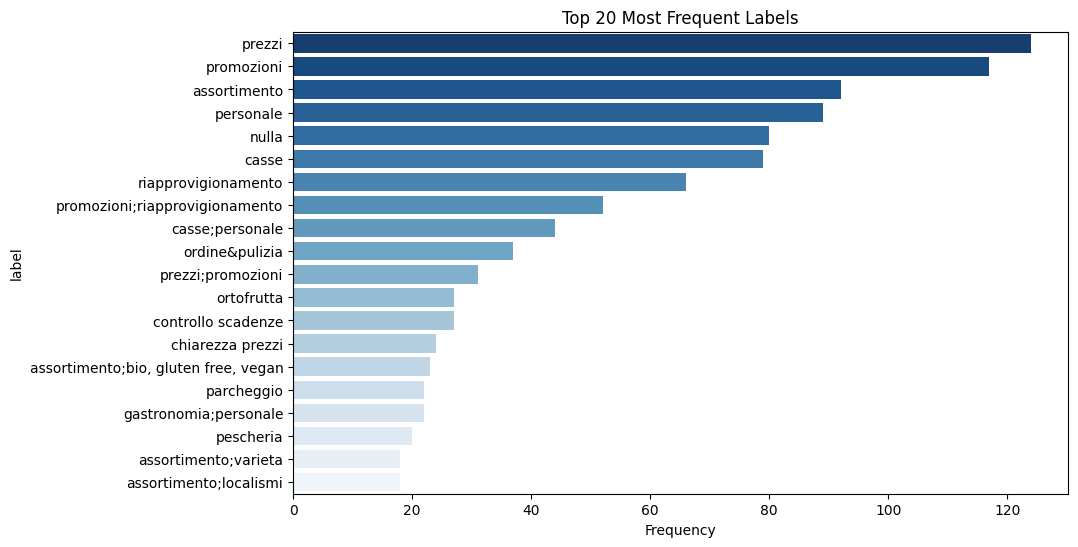

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
top_20_labels = data_cleaned.label.value_counts()[:20]
palette = list(reversed(sns.color_palette("Blues", n_colors=20)))
plt.figure(figsize=(10, 6))
sns.barplot(x=top_20_labels.values, y=top_20_labels.index, palette=palette)
plt.title("Top 20 Most Frequent Labels")
plt.xlabel("Frequency")
plt.show()


In [ ]:
data_cleaned['counts'] = data_cleaned.label.apply(lambda x: x.count(";")+1)
labels_comb = data_cleaned[data_cleaned['counts'] > 1]
label_ = data_cleaned[data_cleaned['counts'] == 1]

print(f"cases with multiple labels: {labels_comb.text.nunique()}")
print(f"cases with a single label: {label_.text.nunique()}")

cases with multiple labels: 1218
cases with a single label: 1010


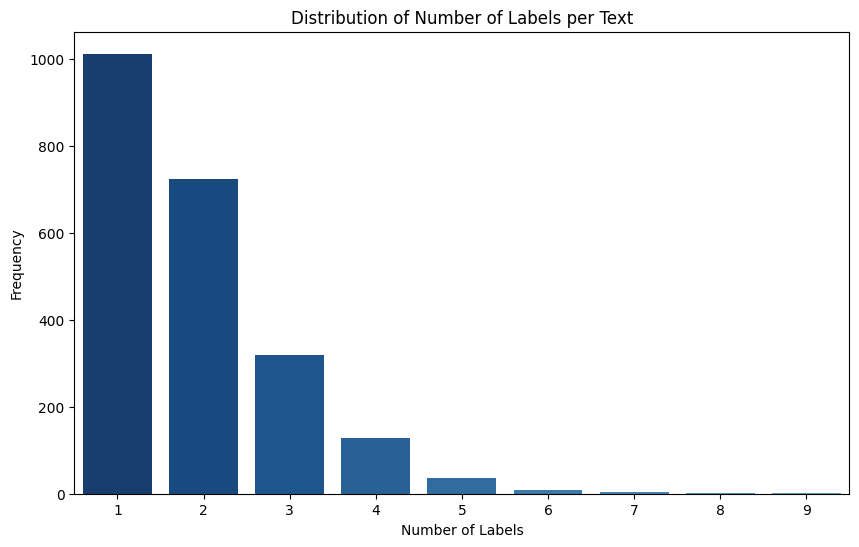

In [ ]:
label_counts_distribution = data_cleaned['counts'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts_distribution.index, y=label_counts_distribution.values, palette=palette)
plt.title("Distribution of Number of Labels per Text")
plt.xlabel("Number of Labels")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("\t\tLABELS' COMBINATIONS")
print(labels_comb.label.nunique())
label_combination_counts = labels_comb.label.value_counts()
print(label_combination_counts[:10])
print('-'*80)
print(label_combination_counts[-10:])

		LABELS' COMBINATIONS
573
label
promozioni;riapprovigionamento          52
casse;personale                         44
prezzi;promozioni                       31
assortimento;bio, gluten free, vegan    23
gastronomia;personale                   22
assortimento;varieta                    18
assortimento;localismi                  18
assortimento;prezzi                     16
assortimento;promozioni                 16
assortimento;riapprovigionamento        15
Name: count, dtype: int64
--------------------------------------------------------------------------------
label
buoni pasto;chiarezza prezzi                                                                       1
casse;pescheria                                                                                    1
ordine&pulizia;personale;promozioni                                                                1
carrelli&cestini;ordine&pulizia;ortofrutta;qualita                                                 1
assortimento;qualita

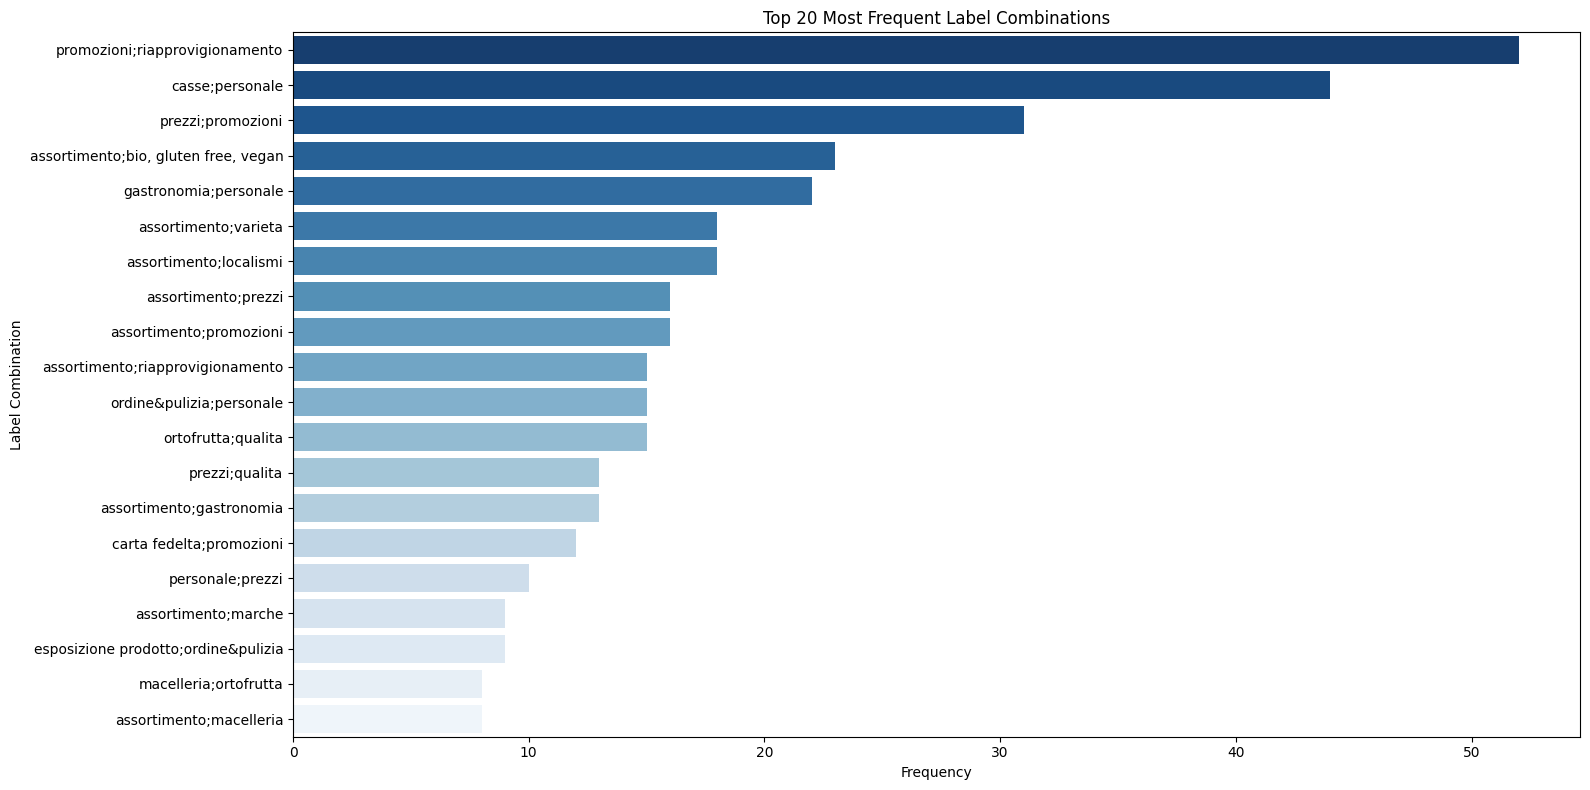

In [ ]:
top_10_combinations = label_combination_counts[:20]
all_combination_counts = label_combination_counts.values
plt.figure(figsize=(16, 8))

sns.barplot(x=top_10_combinations.values, y=top_10_combinations.index, palette=palette)
plt.title("Top 20 Most Frequent Label Combinations")
plt.xlabel("Frequency")
plt.ylabel("Label Combination")

plt.tight_layout()
plt.show()


		Single label
Number of unique labels: 40
single labels:
label
prezzi                     124
promozioni                 117
assortimento                92
personale                   89
nulla                       80
casse                       79
riapprovigionamento         66
ordine&pulizia              37
controllo scadenze          27
ortofrutta                  27
chiarezza prezzi            24
parcheggio                  22
pescheria                   20
spesa online                17
macelleria                  16
buoni pasto                 15
panetteria                  15
carta fedelta               14
gastronomia                 14
volantini                   12
esposizione prodotto        12
varieta                     10
qualita                     10
freschezza                   8
orari                        8
carrelli&cestini             8
localismi                    7
marche                       6
drug                         5
sostenibilita                5
bio, g

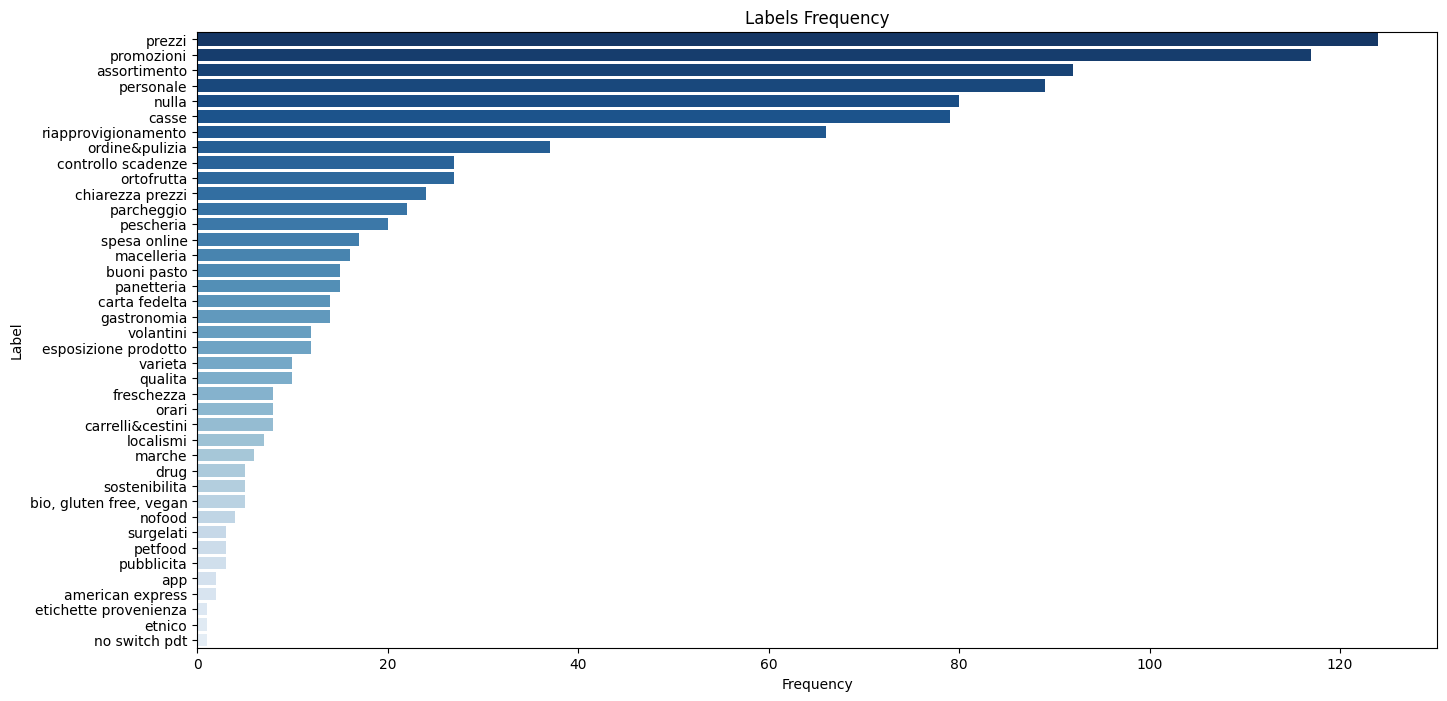

In [ ]:
unique_labels_count = label_.label.nunique()
print(f"\t\tSingle label")
print(f"Number of unique labels: {unique_labels_count}")


label_combination_counts = label_.label.value_counts()

print("single labels:")
print(label_combination_counts)

palette = list(reversed(sns.color_palette("Blues", n_colors=44)))
plt.figure(figsize=(16, 8))
sns.barplot(x=label_combination_counts[:40].values, y=label_combination_counts[:40].index, palette=palette)
plt.title("Labels Frequency")
plt.xlabel("Frequency")
plt.ylabel("Label")
plt.show()


In [ ]:
label_counts = data_cleaned['label'].str.split(';').explode().value_counts()
rare_labels = label_counts[label_counts < 30].index
print("Labels with fewer than 30 occurrences:")
print(rare_labels)

Labels with fewer than 30 occurrences:
Index(['buoni pasto', 'carrelli&cestini', 'petfood', 'app', 'orari', 'nofood',
       'sostenibilita', 'pubblicita', 'etichette provenienza', 'km 0',
       'american express', 'etnico', 'no switch pdt'],
      dtype='object', name='label')


In [ ]:
data_cleaned['label_list'] = data_cleaned['label'].apply(lambda x: x.split(';'))

for idx, lists in enumerate(data_cleaned['label_list']):
    if any(label in rare_labels for label in lists):
        data_cleaned.drop(idx, inplace=True)

data_cleaned.reset_index(drop=True, inplace=True)
print(data_cleaned.shape)

(2115, 4)


In [ ]:
label_counts = data_cleaned['label_list'].explode().value_counts()

print("Number of unique labels:", label_counts.shape[0])
print("Unique labels with counts:")
print(label_counts)

Number of unique labels: 28
Unique labels with counts:
label_list
assortimento               497
prezzi                     359
promozioni                 355
personale                  346
riapprovigionamento        234
casse                      232
ortofrutta                 230
qualita                    174
ordine&pulizia             170
gastronomia                151
macelleria                 129
pescheria                  122
freschezza                 109
varieta                    108
localismi                   88
nulla                       81
chiarezza prezzi            70
panetteria                  69
esposizione prodotto        67
bio, gluten free, vegan     61
parcheggio                  56
marche                      55
controllo scadenze          45
carta fedelta               45
volantini                   33
spesa online                32
drug                        30
surgelati                   27
Name: count, dtype: int64


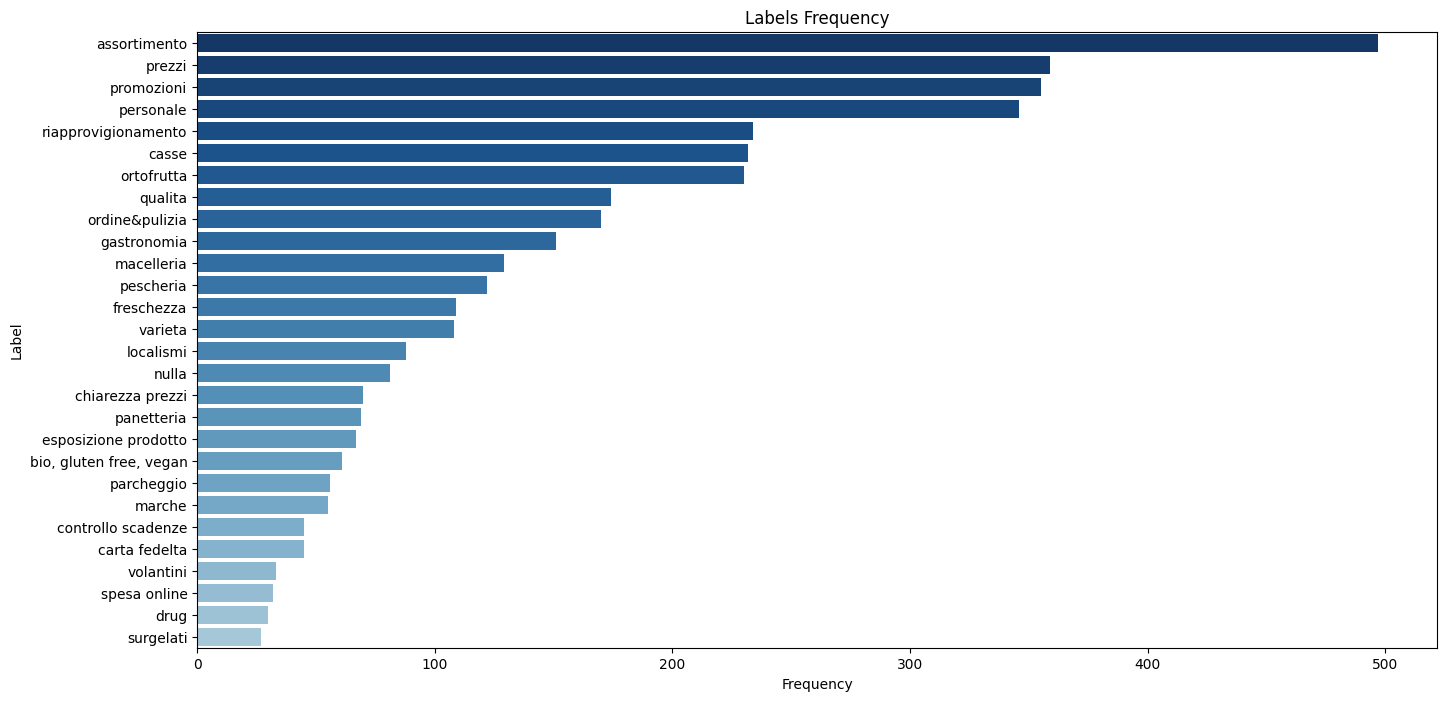

In [ ]:
palette = list(reversed(sns.color_palette("Blues", n_colors=44)))

plt.figure(figsize=(16, 8))
sns.barplot(x=label_counts[:40].values, y=label_counts[:40].index, palette=palette)
plt.title("Labels Frequency")
plt.xlabel("Frequency")
plt.ylabel("Label")
plt.show()

In [ ]:
mlb = MultiLabelBinarizer()
binary_matrix = mlb.fit_transform(data_cleaned['label_list'])
label_names = mlb.classes_

binary_df = pd.DataFrame(binary_matrix, columns=label_names)
co_occurrence = binary_df.T.dot(binary_df)

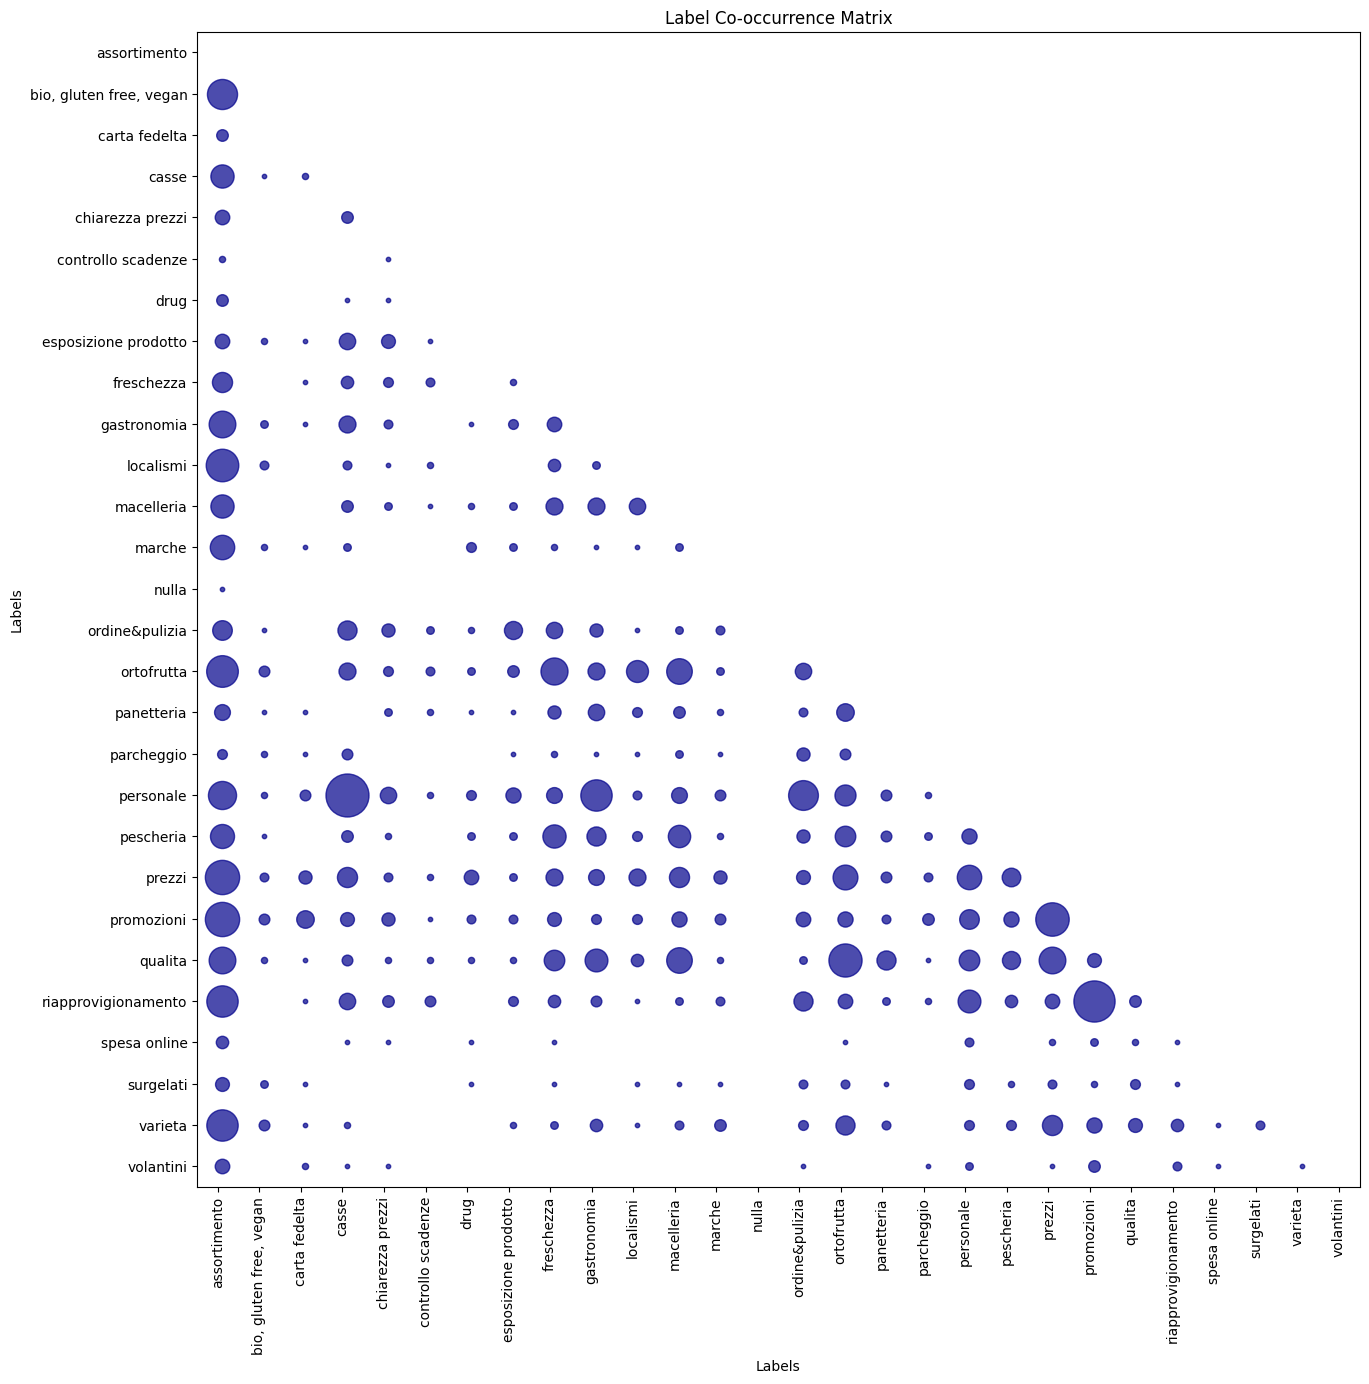

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15))

for i in range(co_occurrence.shape[0]):
    for j in range(0, i):
        size = co_occurrence.iloc[i, j]
        if size > 0:
            ax.scatter(j + 0.1, i, s=size*10, color='darkblue', alpha=0.7)


ax.set_xticks(np.arange(len(label_names)))
ax.set_yticks(np.arange(len(label_names)))
ax.set_xticklabels(label_names, rotation=90)
ax.set_yticklabels(label_names)

ax.set_xlim([-0.5, co_occurrence.shape[0] - 0.5])
ax.set_ylim([co_occurrence.shape[1] - 0.5, -0.5])

plt.title("Label Co-occurrence Matrix")
plt.xlabel("Labels")
plt.ylabel("Labels")
plt.grid(False)
plt.show()

# Data sampling

In [ ]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

def dataframe_creation(df):
    mlb = MultiLabelBinarizer()
    label_binarized = mlb.fit_transform(df['label_list'])

    df_coded = pd.DataFrame(label_binarized, columns=mlb.classes_, index=df.index)
    df_coded['text'] = df['text'].values
    df_coded.reset_index(drop=True, inplace=True)

    df_coded['tag_list'] = df_coded[mlb.classes_].values.tolist()
    df_coded['label_names'] = df_coded['tag_list'].apply(lambda tags: [mlb.classes_[i] for i, tag in enumerate(tags) if tag == 1])

    new_df = df_coded[['text', 'tag_list', 'label_names']].copy()
    new_df['label_count'] = new_df['tag_list'].apply(lambda x: sum(x))

    return new_df, mlb.classes_

In [ ]:
df, label_names = dataframe_creation(data_cleaned)

print("\nUnique label names:", label_names)
df.head()


Unique label names: ['assortimento' 'bio, gluten free, vegan' 'carta fedelta' 'casse'
 'chiarezza prezzi' 'controllo scadenze' 'drug' 'esposizione prodotto'
 'freschezza' 'gastronomia' 'localismi' 'macelleria' 'marche' 'nulla'
 'ordine&pulizia' 'ortofrutta' 'panetteria' 'parcheggio' 'personale'
 'pescheria' 'prezzi' 'promozioni' 'qualita' 'riapprovigionamento'
 'spesa online' 'surgelati' 'varieta' 'volantini']


,text,tag_list,label_names,label_count
0,personale servizio barriera casse,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[casse, personale]",2
1,pulizia professionalita responsabili punto ven...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[ordine&pulizia, personale, promozioni]",3
2,varieta scaffali ben riforniti quando offerte ...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[promozioni, riapprovigionamento, varieta]",3
3,sicuramente cortesia casse,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[casse, personale]",2
4,prodotti freschi senza glutine,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[bio, gluten free, vegan]",1


# Classical ML settings

In [ ]:
y = np.array(df['tag_list'].tolist())
y.shape

(2115, 28)

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(df["text"], y, test_size=0.2, random_state=934, shuffle=True)

print(f"Training data: {X_train_raw.shape}, {y_train.shape}")
print(f"Test data: {X_test_raw.shape}, {y_test.shape}")

Training data: (1692,), (1692, 28)
Test data: (423,), (423, 28)


In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1,3), lowercase=False,
                        max_df=0.8,
                        min_df=5)

X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

num_class = y_train.shape[1]
w_class = np.zeros(num_class)

for i in range(num_class):
    class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train[:, i])
    w_class[i] = class_weights[1]
w_class_normalized = w_class / w_class.sum()

class_weights_dict = {i: w_class_normalized[i] for i in range(len(w_class_normalized))}
class_weights_dict


{0: 0.005309424641042919,
 1: 0.04536095399847538,
 2: 0.06520637137280837,
 3: 0.011657004938155685,
 4: 0.03597592903327358,
 5: 0.061370702468525516,
 6: 0.08346415535719472,
 7: 0.04012699776788207,
 8: 0.024548280987410208,
 9: 0.016964259218942013,
 10: 0.026751331845254713,
 11: 0.01932040633268396,
 12: 0.05216509709824669,
 13: 0.03365490135370754,
 14: 0.015571670775596028,
 15: 0.01109895682941419,
 16: 0.04012699776788207,
 17: 0.04347091424853891,
 18: 0.007643237670072776,
 19: 0.021291876366631303,
 20: 0.007121514962217978,
 21: 0.007560158999745897,
 22: 0.015120317999491794,
 23: 0.011158309539731914,
 24: 0.10433019419649338,
 25: 0.09484563108772125,
 26: 0.024262835859649622,
 27: 0.07452156728320956}

In [ ]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=934)

X = df["text"].values

for train_index, test_index in mskf.split(X, y):
    X_train_rawS, X_test_rawS = X[train_index], X[test_index]
    y_trainS, y_testS = y[train_index], y[test_index]
    break

print(f"Training data: {X_train_rawS.shape}, {y_trainS.shape}")
print(f"Test data: {X_test_rawS.shape}, {y_testS.shape}")

Training data: (1696,), (1696, 28)
Test data: (419,), (419, 28)


In [ ]:
X_trainS = tfidf.fit_transform(X_train_rawS)
X_testS = tfidf.transform(X_test_rawS)

## Decision tree

### without weights

In [ ]:
%time
decision_tree = DecisionTreeClassifier(random_state=193)

multi_decision_tree = OneVsRestClassifier(estimator=decision_tree)
multi_decision_tree.fit(X_train,y_train)
y_pred = multi_decision_tree.predict(X_test)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 7.63 µs


In [ ]:
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.65      0.67      0.66       104
bio, gluten free, vegan       0.70      0.47      0.56        15
          carta fedelta       0.78      0.54      0.64        13
                  casse       0.91      0.92      0.92        53
       chiarezza prezzi       0.60      0.50      0.55        12
     controllo scadenze       0.50      0.45      0.48        11
                   drug       0.50      0.60      0.55         5
   esposizione prodotto       0.50      0.33      0.40        15
             freschezza       0.68      0.71      0.69        24
            gastronomia       0.81      0.93      0.87        28
              localismi       0.53      0.90      0.67        10
             macelleria       0.83      0.95      0.89        21
                 marche       0.78      0.47      0.58        15
                  nulla       0.56      0.47      0.51        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))
y_pred_proba = multi_decision_tree.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_test, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.035123269165822354
Macro AUC-ROC for the multi-label model: 0.8400848374073728
Macro AUC-ROC for the multi-label model: 0.8627929953616686
Weighted AUC-ROC for the multi-label model: 0.8509676071114607


AUC for Label 'assortimento': 0.77
AUC for Label 'bio, gluten free, vegan': 0.73
AUC for Label 'carta fedelta': 0.77
AUC for Label 'casse': 0.96
AUC for Label 'chiarezza prezzi': 0.74
AUC for Label 'controllo scadenze': 0.72
AUC for Label 'drug': 0.78
AUC for Label 'esposizione prodotto': 0.66
AUC for Label 'freschezza': 0.87
AUC for Label 'gastronomia': 0.95
AUC for Label 'localismi': 0.99
AUC for Label 'macelleria': 0.97
AUC for Label 'marche': 0.73
AUC for Label 'nulla': 0.86
AUC for Label 'ordine&pulizia': 0.86
AUC for Label 'ortofrutta': 0.92
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.87
AUC for Label 'personale': 0.84
AUC for Label 'pescheria': 0.93
AUC for Label 'prezzi': 0.85
AUC for Label 'promozioni': 0.89
AUC for Label 'qualita': 0.88
AUC for Label 'riapprovigionamento': 0.79
AUC for Label 'spesa online': 0.83
AUC for Label 'surgelati': 0.70
AUC for Label 'varieta': 0.74
AUC for Label 'volantini': 0.89


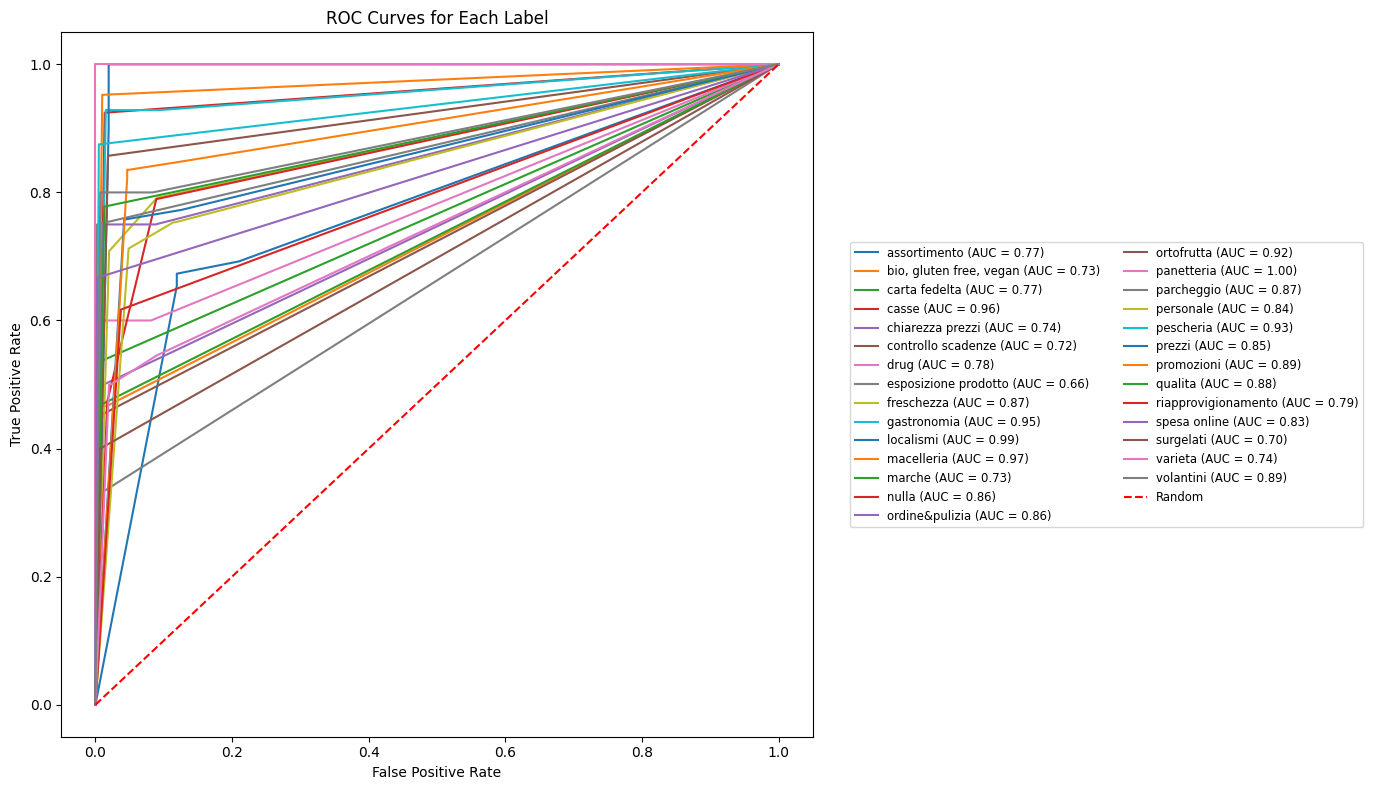

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

### with weights

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=193, class_weight = class_weights_dict)

multi_decision_tree = OneVsRestClassifier(estimator=decision_tree)
multi_decision_tree.fit(X_train,y_train)
y_pred = multi_decision_tree.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.48      0.68      0.56       104
bio, gluten free, vegan       0.57      0.53      0.55        15
          carta fedelta       0.73      0.62      0.67        13
                  casse       0.87      0.91      0.89        53
       chiarezza prezzi       0.47      0.67      0.55        12
     controllo scadenze       0.64      0.64      0.64        11
                   drug       0.56      1.00      0.71         5
   esposizione prodotto       0.33      0.33      0.33        15
             freschezza       0.49      0.75      0.59        24
            gastronomia       0.84      0.93      0.88        28
              localismi       0.83      1.00      0.91        10
             macelleria       0.88      1.00      0.93        21
                 marche       0.91      0.67      0.77        15
                  nulla       0.30      0.84      0.44        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

hamming loss:  0.04871664978047957


In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))
y_pred_proba = multi_decision_tree.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_test, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.04871664978047957
Macro AUC-ROC for the multi-label model: 0.8715296896516264
Macro AUC-ROC for the multi-label model: 0.8760625832287257
Weighted AUC-ROC for the multi-label model: 0.8618234754985268


AUC for Label 'assortimento': 0.75
AUC for Label 'bio, gluten free, vegan': 0.76
AUC for Label 'carta fedelta': 0.80
AUC for Label 'casse': 0.94
AUC for Label 'chiarezza prezzi': 0.82
AUC for Label 'controllo scadenze': 0.81
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.65
AUC for Label 'freschezza': 0.88
AUC for Label 'gastronomia': 0.96
AUC for Label 'localismi': 1.00
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.83
AUC for Label 'nulla': 0.89
AUC for Label 'ordine&pulizia': 0.86
AUC for Label 'ortofrutta': 0.96
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.94
AUC for Label 'personale': 0.88
AUC for Label 'pescheria': 0.93
AUC for Label 'prezzi': 0.84
AUC for Label 'promozioni': 0.91
AUC for Label 'qualita': 0.86
AUC for Label 'riapprovigionamento': 0.80
AUC for Label 'spesa online': 0.83
AUC for Label 'surgelati': 0.80
AUC for Label 'varieta': 0.72
AUC for Label 'volantini': 0.99


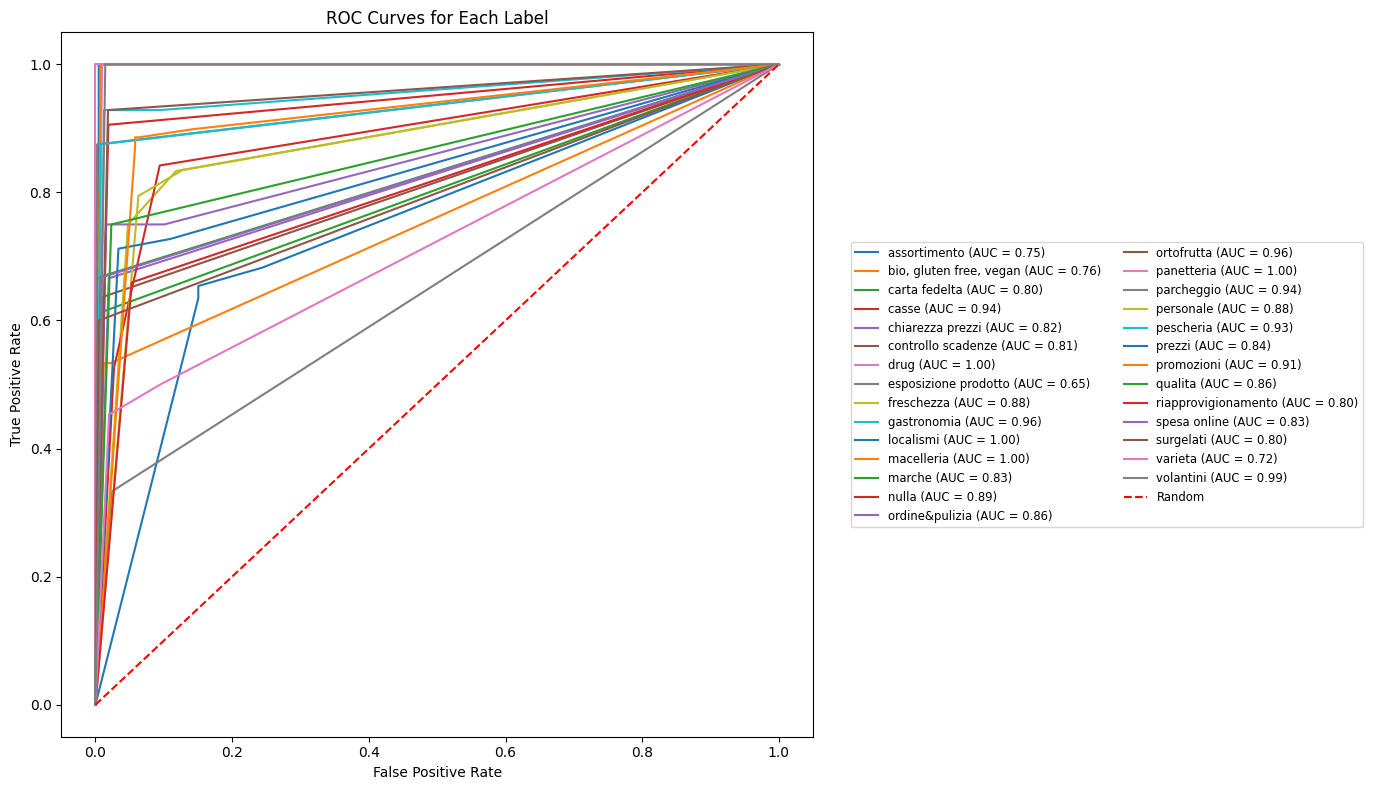

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

### stratified

In [ ]:
multi_decision_tree = OneVsRestClassifier(estimator=decision_tree)
multi_decision_tree.fit(X_trainS,y_trainS)
y_pred = multi_decision_tree.predict(X_testS)

In [ ]:
print(classification_report(y_testS, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.52      0.58      0.55       100
bio, gluten free, vegan       0.86      0.46      0.60        13
          carta fedelta       0.78      0.78      0.78         9
                  casse       0.90      0.91      0.91        47
       chiarezza prezzi       0.35      0.50      0.41        14
     controllo scadenze       0.70      0.78      0.74         9
                   drug       0.62      0.83      0.71         6
   esposizione prodotto       0.33      0.29      0.31        14
             freschezza       0.59      0.77      0.67        22
            gastronomia       0.77      0.90      0.83        30
              localismi       0.60      0.83      0.70        18
             macelleria       0.86      0.92      0.89        26
                 marche       0.44      0.36      0.40        11
                  nulla       0.73      0.69      0.71        16
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_testS, y_pred))

y_pred_proba = multi_decision_tree.predict_proba(X_testS)
auc_roc_macro = roc_auc_score(y_testS, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_testS, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_testS, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.041339924991476304
Macro AUC-ROC for the multi-label model: 0.8569002024857336
Macro AUC-ROC for the multi-label model: 0.8720129673662553
Weighted AUC-ROC for the multi-label model: 0.8591347806415242


AUC for Label 'assortimento': 0.72
AUC for Label 'bio, gluten free, vegan': 0.72
AUC for Label 'carta fedelta': 0.89
AUC for Label 'casse': 0.95
AUC for Label 'chiarezza prezzi': 0.73
AUC for Label 'controllo scadenze': 0.89
AUC for Label 'drug': 0.91
AUC for Label 'esposizione prodotto': 0.63
AUC for Label 'freschezza': 0.87
AUC for Label 'gastronomia': 0.94
AUC for Label 'localismi': 0.91
AUC for Label 'macelleria': 0.96
AUC for Label 'marche': 0.68
AUC for Label 'nulla': 0.93
AUC for Label 'ordine&pulizia': 0.87
AUC for Label 'ortofrutta': 0.94
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 1.00
AUC for Label 'personale': 0.82
AUC for Label 'pescheria': 0.98
AUC for Label 'prezzi': 0.91
AUC for Label 'promozioni': 0.92
AUC for Label 'qualita': 0.89
AUC for Label 'riapprovigionamento': 0.81
AUC for Label 'spesa online': 1.00
AUC for Label 'surgelati': 0.70
AUC for Label 'varieta': 0.77
AUC for Label 'volantini': 0.70


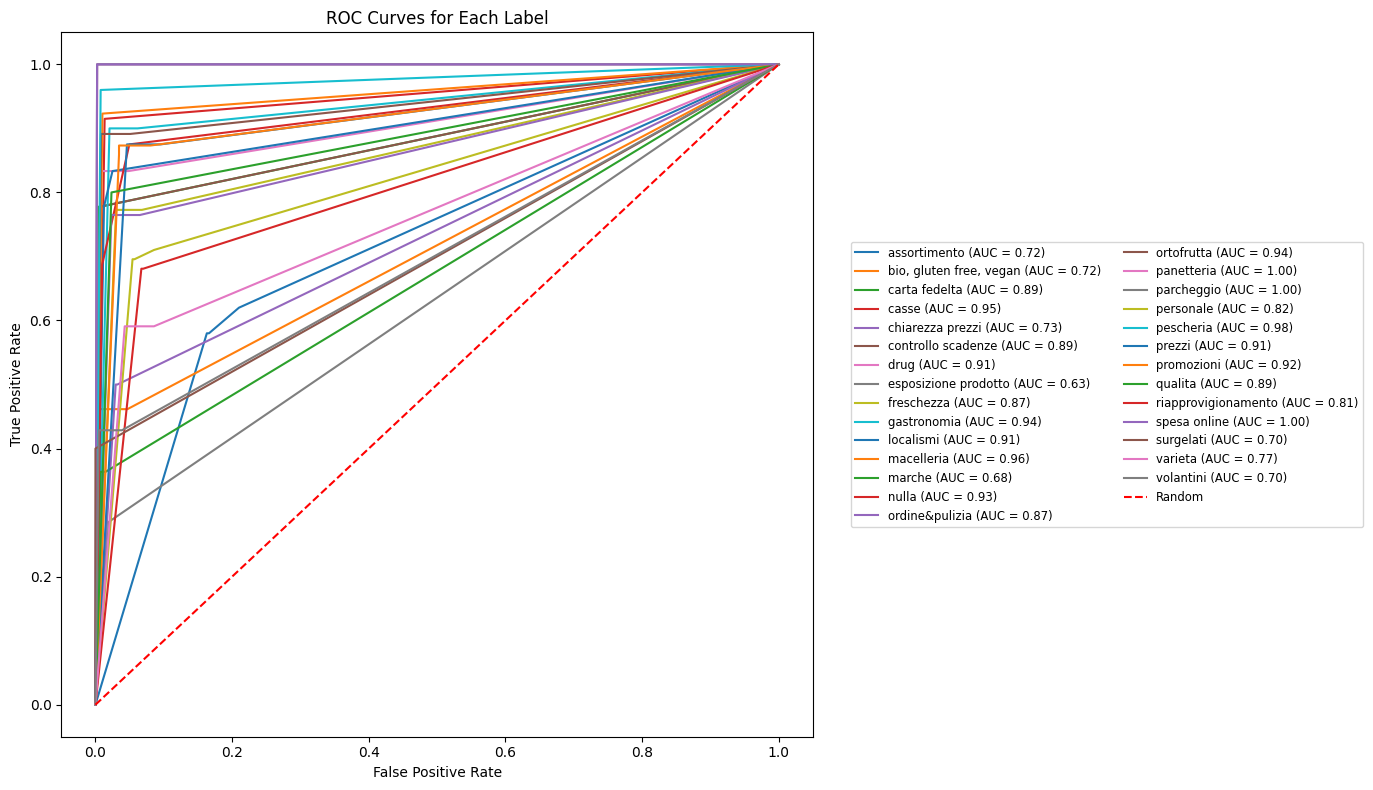

In [ ]:
draw_aucroc(y_testS, y_pred_proba, label_names)

## SVM linear

In [ ]:
from sklearn.svm import SVC, LinearSVC

### without weights

In [ ]:
svm = SVC(kernel='linear', probability=True, random_state=934)
multi_svm = OneVsRestClassifier(svm)
multi_svm.fit(X_train, y_train)

y_pred = multi_svm.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.85      0.54      0.66       104
bio, gluten free, vegan       0.78      0.47      0.58        15
          carta fedelta       0.75      0.23      0.35        13
                  casse       0.86      0.81      0.83        53
       chiarezza prezzi       1.00      0.25      0.40        12
     controllo scadenze       0.83      0.45      0.59        11
                   drug       1.00      0.60      0.75         5
   esposizione prodotto       0.75      0.20      0.32        15
             freschezza       0.80      0.33      0.47        24
            gastronomia       0.88      0.79      0.83        28
              localismi       0.88      0.70      0.78        10
             macelleria       0.95      0.95      0.95        21
                 marche       0.78      0.47      0.58        15
                  nulla       0.64      0.47      0.55        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

y_pred_proba = multi_svm.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_test, y_pred_proba, average="weighted")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.030395136778115502
Macro AUC-ROC for the multi-label model: 0.9437598237762606
Macro AUC-ROC for the multi-label model: 0.9643304034305914
Macro AUC-ROC for the multi-label model: 0.9428873574244444


AUC for Label 'assortimento': 0.90
AUC for Label 'bio, gluten free, vegan': 0.90
AUC for Label 'carta fedelta': 0.88
AUC for Label 'casse': 0.99
AUC for Label 'chiarezza prezzi': 0.90
AUC for Label 'controllo scadenze': 0.99
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.89
AUC for Label 'freschezza': 0.93
AUC for Label 'gastronomia': 0.99
AUC for Label 'localismi': 0.98
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.99
AUC for Label 'nulla': 0.95
AUC for Label 'ordine&pulizia': 0.90
AUC for Label 'ortofrutta': 0.98
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.95
AUC for Label 'personale': 0.95
AUC for Label 'pescheria': 1.00
AUC for Label 'prezzi': 0.97
AUC for Label 'promozioni': 0.95
AUC for Label 'qualita': 0.93
AUC for Label 'riapprovigionamento': 0.92
AUC for Label 'spesa online': 0.93
AUC for Label 'surgelati': 0.84
AUC for Label 'varieta': 0.82
AUC for Label 'volantini': 0.99


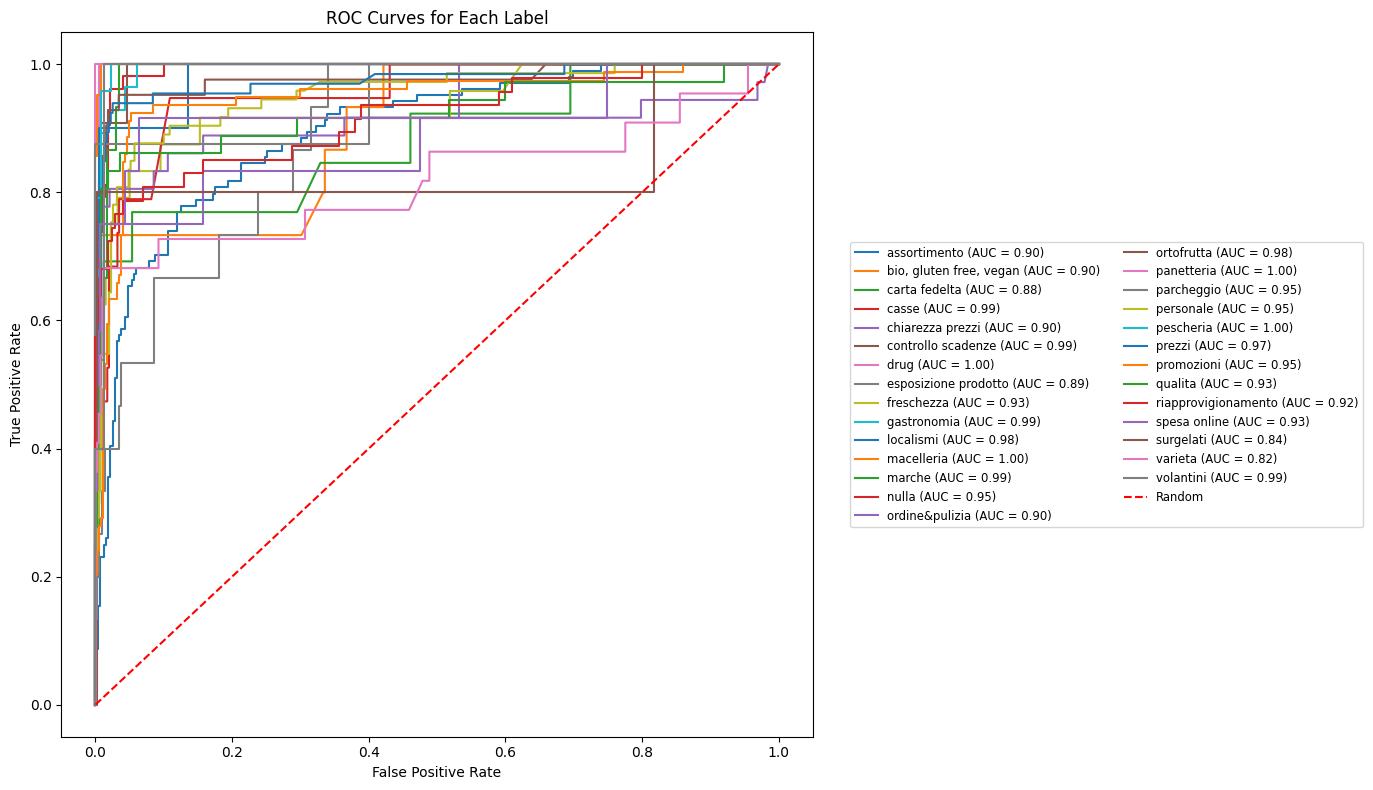

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

### with weights

In [ ]:
svm = SVC(kernel='linear', probability=True, class_weight=class_weights_dict, random_state=934)
multi_svm = OneVsRestClassifier(svm)
multi_svm.fit(X_train, y_train)

y_pred = multi_svm.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.25      1.00      0.39       104
bio, gluten free, vegan       0.00      0.00      0.00        15
          carta fedelta       0.00      0.00      0.00        13
                  casse       1.00      0.38      0.55        53
       chiarezza prezzi       0.00      0.00      0.00        12
     controllo scadenze       0.00      0.00      0.00        11
                   drug       0.00      0.00      0.00         5
   esposizione prodotto       0.00      0.00      0.00        15
             freschezza       0.00      0.00      0.00        24
            gastronomia       0.00      0.00      0.00        28
              localismi       0.00      0.00      0.00        10
             macelleria       0.00      0.00      0.00        21
                 marche       0.00      0.00      0.00        15
                  nulla       0.00      0.00      0.00        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

y_pred_proba = multi_svm.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_test, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.18085106382978725
Macro AUC-ROC for the multi-label model: 0.9609145702159685
Macro AUC-ROC for the multi-label model: 0.9617667616562395
Weighted AUC-ROC for the multi-label model: 0.9541765583349674


AUC for Label 'assortimento': 0.91
AUC for Label 'bio, gluten free, vegan': 0.96
AUC for Label 'carta fedelta': 0.96
AUC for Label 'casse': 0.98
AUC for Label 'chiarezza prezzi': 0.94
AUC for Label 'controllo scadenze': 1.00
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.91
AUC for Label 'freschezza': 0.97
AUC for Label 'gastronomia': 0.99
AUC for Label 'localismi': 0.99
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.99
AUC for Label 'nulla': 0.96
AUC for Label 'ordine&pulizia': 0.92
AUC for Label 'ortofrutta': 0.99
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.95
AUC for Label 'personale': 0.95
AUC for Label 'pescheria': 1.00
AUC for Label 'prezzi': 0.96
AUC for Label 'promozioni': 0.96
AUC for Label 'qualita': 0.95
AUC for Label 'riapprovigionamento': 0.95
AUC for Label 'spesa online': 0.95
AUC for Label 'surgelati': 0.89
AUC for Label 'varieta': 0.89
AUC for Label 'volantini': 1.00


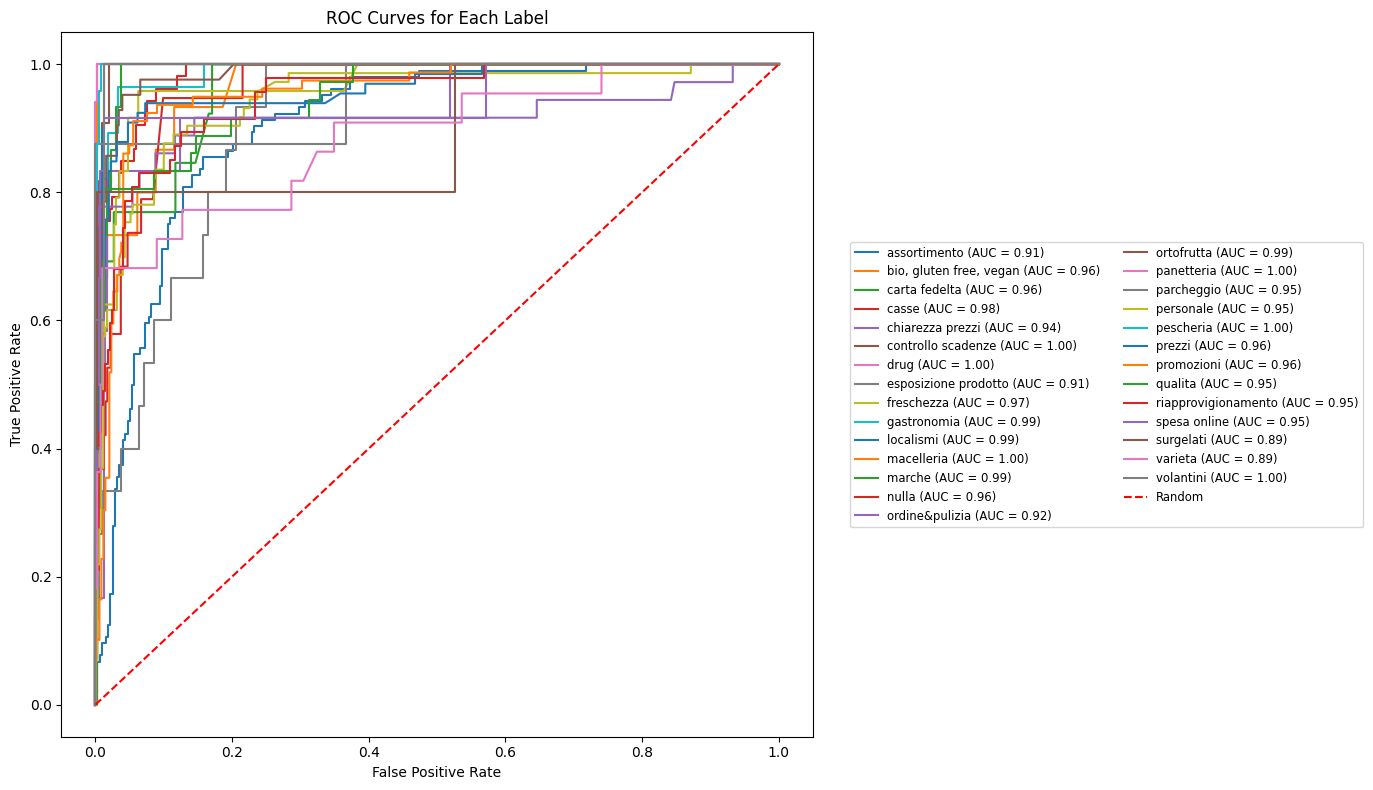

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

### stratified

In [ ]:
svm = SVC(kernel='linear', probability=True, random_state=934)
multi_svm = OneVsRestClassifier(svm)
multi_svm.fit(X_trainS, y_trainS)

y_pred = multi_svm.predict(X_testS)

print(classification_report(y_testS, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.77      0.61      0.68       100
bio, gluten free, vegan       1.00      0.38      0.56        13
          carta fedelta       0.67      0.22      0.33         9
                  casse       0.95      0.85      0.90        47
       chiarezza prezzi       0.50      0.07      0.12        14
     controllo scadenze       1.00      0.44      0.62         9
                   drug       1.00      0.33      0.50         6
   esposizione prodotto       1.00      0.29      0.44        14
             freschezza       0.92      0.55      0.69        22
            gastronomia       0.83      0.67      0.74        30
              localismi       1.00      0.56      0.71        18
             macelleria       0.92      0.92      0.92        26
                 marche       0.71      0.45      0.56        11
                  nulla       0.91      0.62      0.74        16
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_testS, y_pred))

y_pred_proba = multi_svm.predict_proba(X_testS)
auc_roc_macro = roc_auc_score(y_testS, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_testS, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_testS, y_pred_proba, average="weighted")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.027361063757245143
Macro AUC-ROC for the multi-label model: 0.940287364217027
Macro AUC-ROC for the multi-label model: 0.9673412423170964
Macro AUC-ROC for the multi-label model: 0.946598904898583


AUC for Label 'assortimento': 0.87
AUC for Label 'bio, gluten free, vegan': 0.89
AUC for Label 'carta fedelta': 0.93
AUC for Label 'casse': 1.00
AUC for Label 'chiarezza prezzi': 0.95
AUC for Label 'controllo scadenze': 0.91
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.75
AUC for Label 'freschezza': 0.93
AUC for Label 'gastronomia': 0.97
AUC for Label 'localismi': 0.99
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.83
AUC for Label 'nulla': 0.94
AUC for Label 'ordine&pulizia': 0.94
AUC for Label 'ortofrutta': 0.99
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 1.00
AUC for Label 'personale': 0.92
AUC for Label 'pescheria': 1.00
AUC for Label 'prezzi': 0.99
AUC for Label 'promozioni': 0.98
AUC for Label 'qualita': 0.96
AUC for Label 'riapprovigionamento': 0.96
AUC for Label 'spesa online': 1.00
AUC for Label 'surgelati': 0.81
AUC for Label 'varieta': 0.87
AUC for Label 'volantini': 0.95


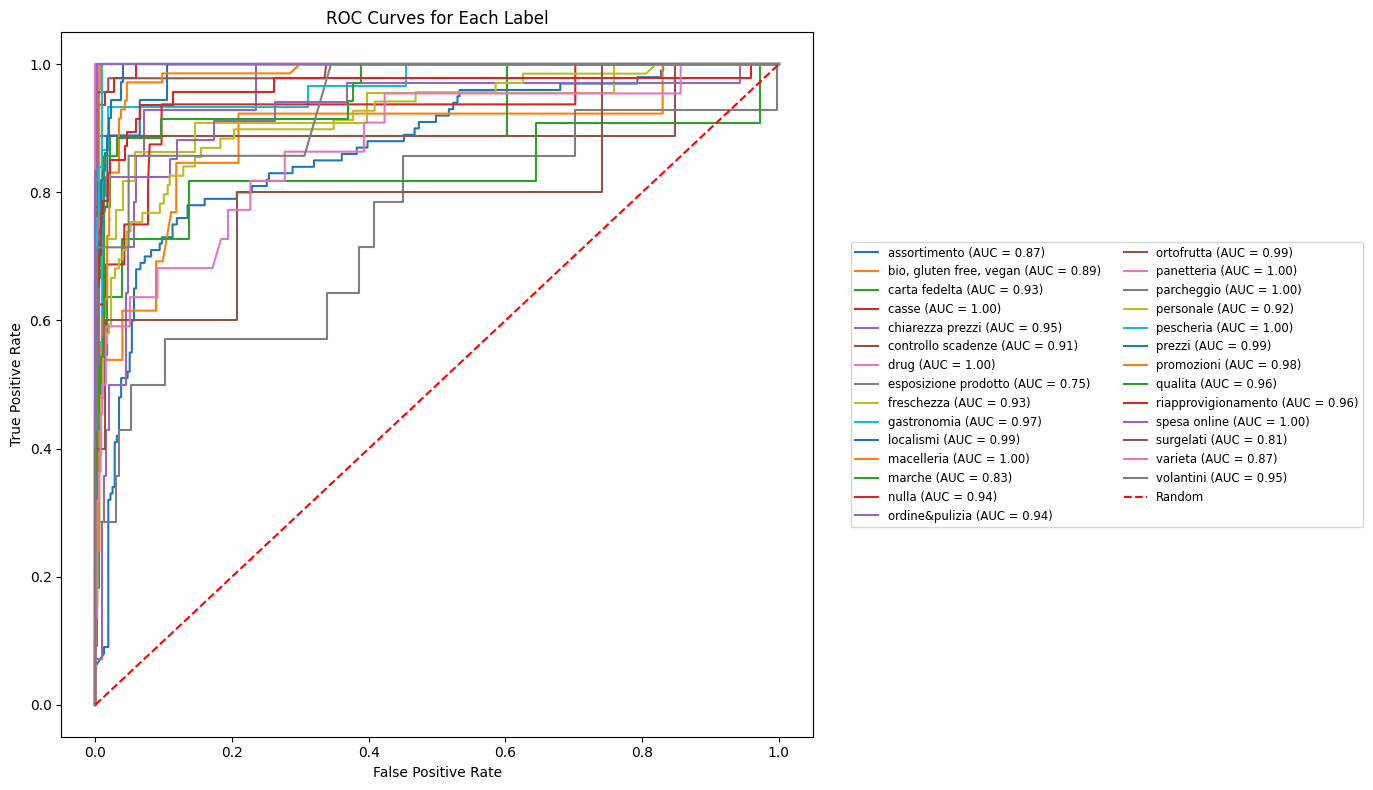

In [ ]:
draw_aucroc(y_testS, y_pred_proba, label_names)

## SVM

### without weights

In [ ]:
svm = SVC(kernel='rbf', probability=True, random_state=934)
multi_svm = OneVsRestClassifier(svm)
multi_svm.fit(X_train, y_train)

y_pred = multi_svm.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.87      0.45      0.59       104
bio, gluten free, vegan       0.78      0.47      0.58        15
          carta fedelta       1.00      0.15      0.27        13
                  casse       0.95      0.74      0.83        53
       chiarezza prezzi       1.00      0.08      0.15        12
     controllo scadenze       0.75      0.27      0.40        11
                   drug       1.00      0.40      0.57         5
   esposizione prodotto       0.67      0.13      0.22        15
             freschezza       1.00      0.17      0.29        24
            gastronomia       0.90      0.64      0.75        28
              localismi       0.83      0.50      0.62        10
             macelleria       0.95      0.86      0.90        21
                 marche       1.00      0.33      0.50        15
                  nulla       1.00      0.32      0.48        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))
y_pred_proba = multi_svm.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_test, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.03579871664978048
Macro AUC-ROC for the multi-label model: 0.949539002161105
Macro AUC-ROC for the multi-label model: 0.9677242095983608
Weighted AUC-ROC for the multi-label model: 0.9503929393730186


AUC for Label 'assortimento': 0.90
AUC for Label 'bio, gluten free, vegan': 0.95
AUC for Label 'carta fedelta': 0.92
AUC for Label 'casse': 0.99
AUC for Label 'chiarezza prezzi': 0.92
AUC for Label 'controllo scadenze': 0.99
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.87
AUC for Label 'freschezza': 0.97
AUC for Label 'gastronomia': 0.99
AUC for Label 'localismi': 0.97
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.99
AUC for Label 'nulla': 0.94
AUC for Label 'ordine&pulizia': 0.91
AUC for Label 'ortofrutta': 0.98
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.89
AUC for Label 'personale': 0.96
AUC for Label 'pescheria': 1.00
AUC for Label 'prezzi': 0.98
AUC for Label 'promozioni': 0.96
AUC for Label 'qualita': 0.94
AUC for Label 'riapprovigionamento': 0.93
AUC for Label 'spesa online': 0.95
AUC for Label 'surgelati': 0.86
AUC for Label 'varieta': 0.84
AUC for Label 'volantini': 0.99


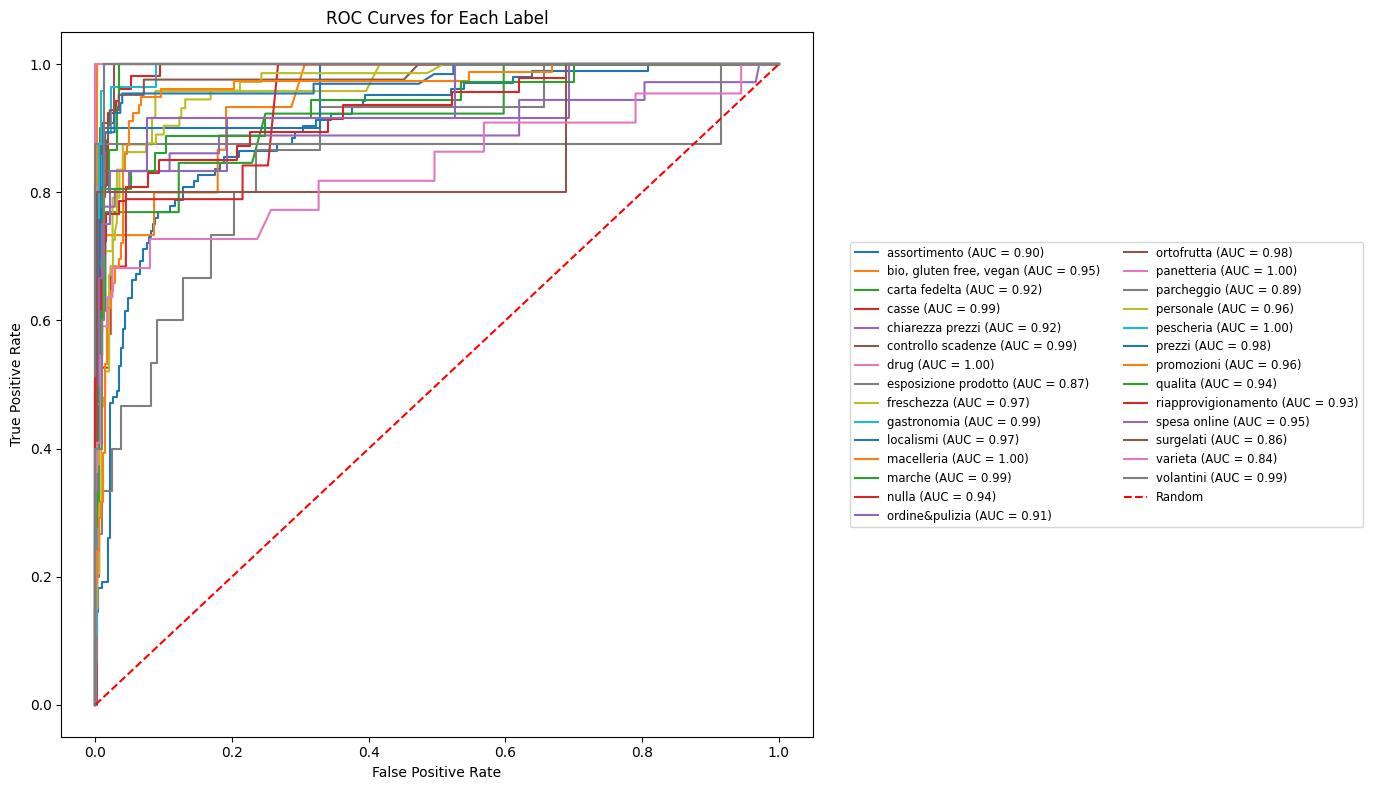

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

### with weights

In [ ]:
svm = SVC(kernel='rbf', probability=True, class_weight=class_weights_dict, random_state=934)
multi_svm = OneVsRestClassifier(svm)
multi_svm.fit(X_train, y_train)

y_pred = multi_svm.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.25      1.00      0.39       104
bio, gluten free, vegan       0.00      0.00      0.00        15
          carta fedelta       0.00      0.00      0.00        13
                  casse       0.13      1.00      0.22        53
       chiarezza prezzi       0.00      0.00      0.00        12
     controllo scadenze       0.00      0.00      0.00        11
                   drug       0.00      0.00      0.00         5
   esposizione prodotto       0.00      0.00      0.00        15
             freschezza       0.00      0.00      0.00        24
            gastronomia       0.00      0.00      0.00        28
              localismi       0.00      0.00      0.00        10
             macelleria       0.00      0.00      0.00        21
                 marche       0.00      0.00      0.00        15
                  nulla       0.00      0.00      0.00        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

y_pred_proba = multi_svm.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_test, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.24062816616008106
Macro AUC-ROC for the multi-label model: 0.9578148045719426
Macro AUC-ROC for the multi-label model: 0.9570958520751169
Weighted AUC-ROC for the multi-label model: 0.9519678025799614


AUC for Label 'assortimento': 0.90
AUC for Label 'bio, gluten free, vegan': 0.96
AUC for Label 'carta fedelta': 0.94
AUC for Label 'casse': 0.98
AUC for Label 'chiarezza prezzi': 0.94
AUC for Label 'controllo scadenze': 0.99
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.90
AUC for Label 'freschezza': 0.96
AUC for Label 'gastronomia': 0.99
AUC for Label 'localismi': 0.99
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.99
AUC for Label 'nulla': 0.97
AUC for Label 'ordine&pulizia': 0.91
AUC for Label 'ortofrutta': 0.97
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.90
AUC for Label 'personale': 0.94
AUC for Label 'pescheria': 1.00
AUC for Label 'prezzi': 0.97
AUC for Label 'promozioni': 0.96
AUC for Label 'qualita': 0.95
AUC for Label 'riapprovigionamento': 0.95
AUC for Label 'spesa online': 0.96
AUC for Label 'surgelati': 0.91
AUC for Label 'varieta': 0.88
AUC for Label 'volantini': 0.99


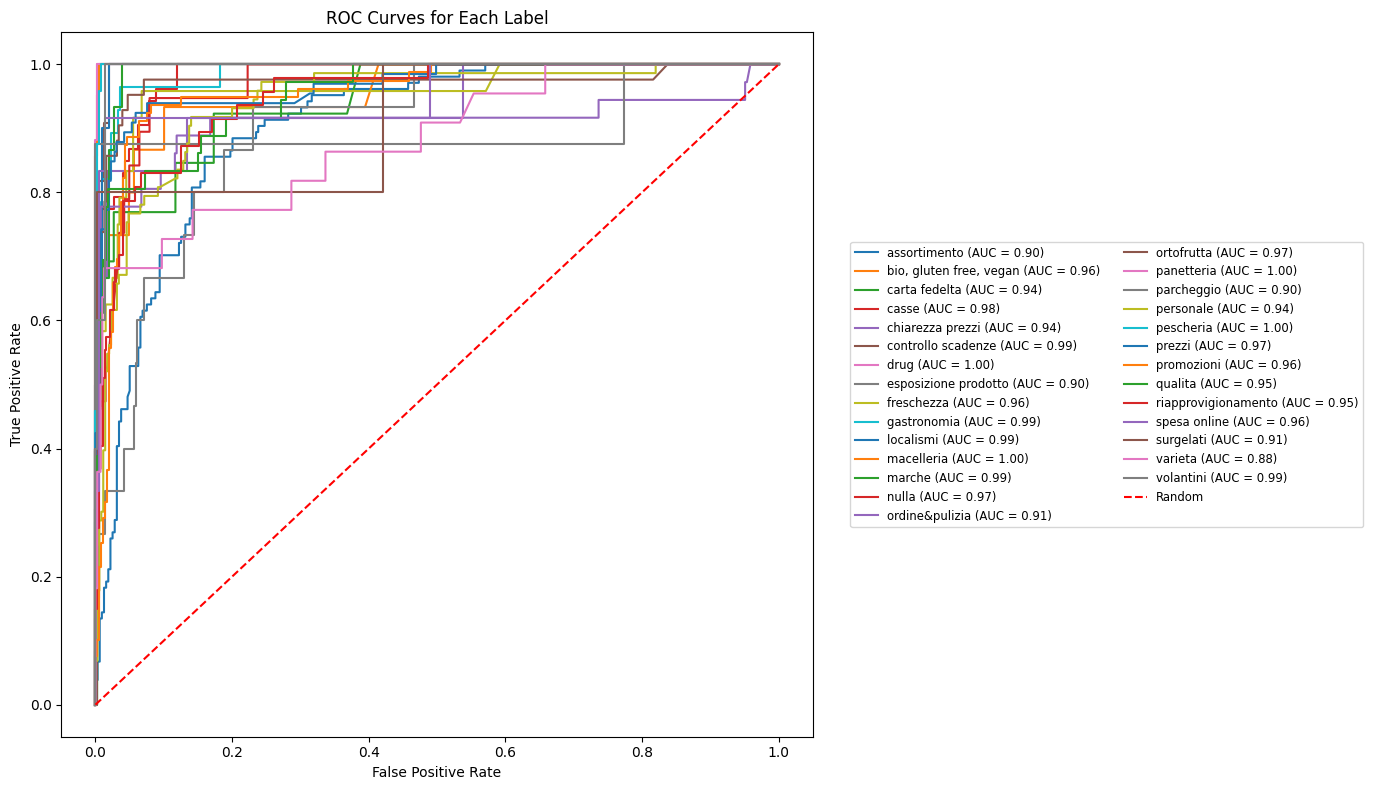

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

### stratified

In [ ]:
svm = SVC(kernel='rbf', probability=True, random_state=934)
multi_svm = OneVsRestClassifier(svm)
multi_svm.fit(X_trainS, y_trainS)

y_pred = multi_svm.predict(X_testS)

print(classification_report(y_testS, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.78      0.54      0.64       100
bio, gluten free, vegan       0.80      0.31      0.44        13
          carta fedelta       1.00      0.22      0.36         9
                  casse       0.95      0.77      0.85        47
       chiarezza prezzi       0.50      0.07      0.12        14
     controllo scadenze       1.00      0.11      0.20         9
                   drug       1.00      0.33      0.50         6
   esposizione prodotto       1.00      0.14      0.25        14
             freschezza       0.91      0.45      0.61        22
            gastronomia       0.88      0.50      0.64        30
              localismi       1.00      0.44      0.62        18
             macelleria       0.95      0.73      0.83        26
                 marche       0.50      0.18      0.27        11
                  nulla       1.00      0.56      0.72        16
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_testS, y_pred))

y_pred_proba = multi_svm.predict_proba(X_testS)
auc_roc_macro = roc_auc_score(y_testS, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_testS, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_testS, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.03298670303443573
Macro AUC-ROC for the multi-label model: 0.9467529610771797
Macro AUC-ROC for the multi-label model: 0.9691108672266749
Weighted AUC-ROC for the multi-label model: 0.9513009465239797


AUC for Label 'assortimento': 0.87
AUC for Label 'bio, gluten free, vegan': 0.90
AUC for Label 'carta fedelta': 0.94
AUC for Label 'casse': 1.00
AUC for Label 'chiarezza prezzi': 0.96
AUC for Label 'controllo scadenze': 0.92
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.78
AUC for Label 'freschezza': 0.96
AUC for Label 'gastronomia': 0.97
AUC for Label 'localismi': 0.97
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.88
AUC for Label 'nulla': 0.92
AUC for Label 'ordine&pulizia': 0.96
AUC for Label 'ortofrutta': 0.99
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 1.00
AUC for Label 'personale': 0.93
AUC for Label 'pescheria': 1.00
AUC for Label 'prezzi': 0.99
AUC for Label 'promozioni': 0.98
AUC for Label 'qualita': 0.97
AUC for Label 'riapprovigionamento': 0.96
AUC for Label 'spesa online': 1.00
AUC for Label 'surgelati': 0.81
AUC for Label 'varieta': 0.89
AUC for Label 'volantini': 0.96


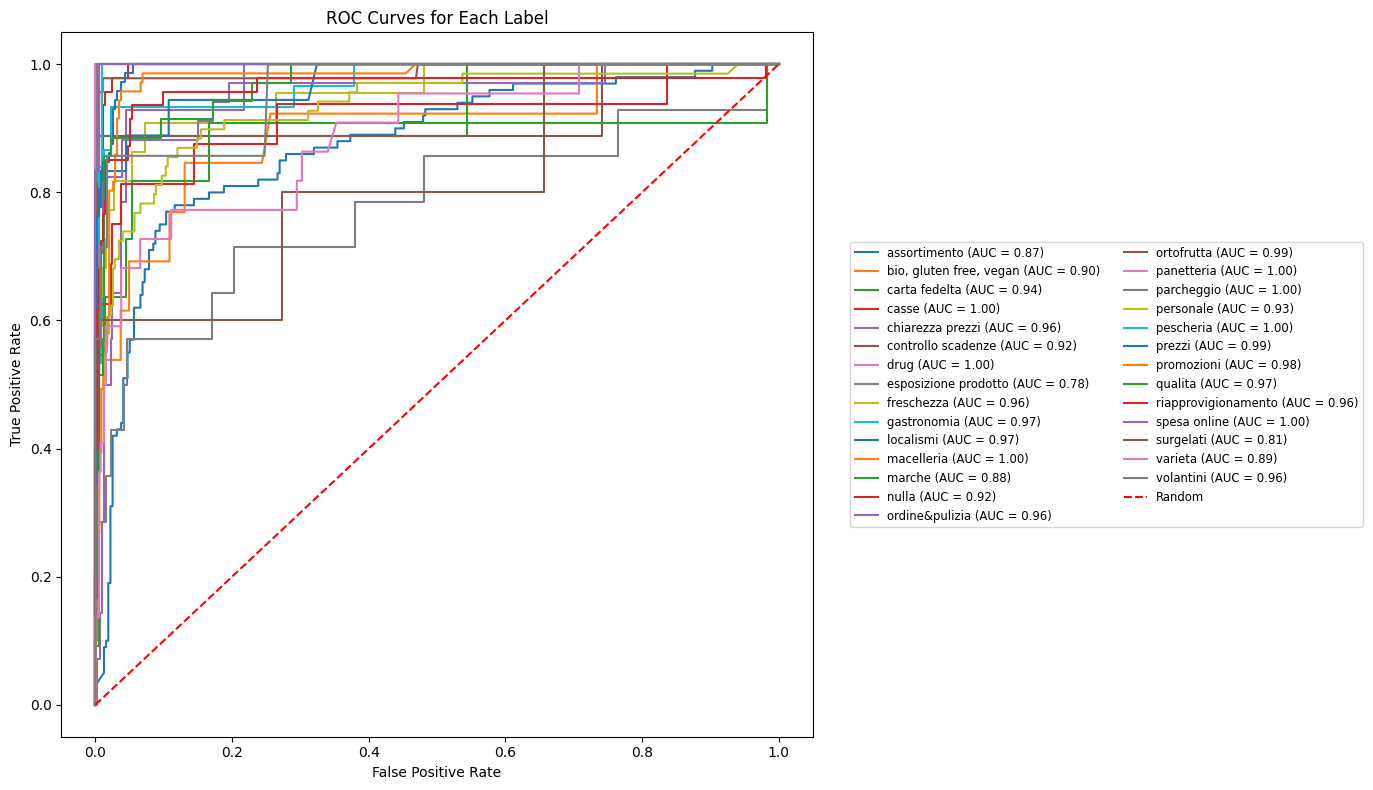

In [ ]:
draw_aucroc(y_testS, y_pred_proba, label_names)

## Linear SVM

### without weights

In [ ]:
linear_svm = OneVsRestClassifier(LinearSVC())
linear_svm.fit(X_train, y_train)
y_pred = linear_svm.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.77      0.54      0.63       104
bio, gluten free, vegan       0.78      0.47      0.58        15
          carta fedelta       1.00      0.31      0.47        13
                  casse       0.86      0.79      0.82        53
       chiarezza prezzi       0.80      0.33      0.47        12
     controllo scadenze       0.88      0.64      0.74        11
                   drug       0.75      0.60      0.67         5
   esposizione prodotto       0.60      0.20      0.30        15
             freschezza       0.85      0.46      0.59        24
            gastronomia       0.88      0.79      0.83        28
              localismi       0.88      0.70      0.78        10
             macelleria       0.95      0.95      0.95        21
                 marche       0.73      0.53      0.62        15
                  nulla       0.67      0.53      0.59        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

y_pred_proba = linear_svm.decision_function(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_test, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.03183046268152651
Macro AUC-ROC for the multi-label model: 0.9488666915856683
Macro AUC-ROC for the multi-label model: 0.9560827606967608
Weighted AUC-ROC for the multi-label model: 0.944304875045292


### with weights

In [ ]:
linear_svm = OneVsRestClassifier(LinearSVC(class_weight=class_weights_dict))
linear_svm.fit(X_train, y_train)
y_pred = linear_svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.25      1.00      0.40       104
bio, gluten free, vegan       0.75      0.20      0.32        15
          carta fedelta       0.00      0.00      0.00        13
                  casse       0.90      0.81      0.85        53
       chiarezza prezzi       0.00      0.00      0.00        12
     controllo scadenze       0.00      0.00      0.00        11
                   drug       0.00      0.00      0.00         5
   esposizione prodotto       0.00      0.00      0.00        15
             freschezza       0.83      0.21      0.33        24
            gastronomia       0.91      0.75      0.82        28
              localismi       1.00      0.50      0.67        10
             macelleria       1.00      0.86      0.92        21
                 marche       0.00      0.00      0.00        15
                  nulla       1.00      0.21      0.35        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

y_pred_proba = linear_svm.decision_function(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_test, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.0707531239446133
Macro AUC-ROC for the multi-label model: 0.9605809343284696
Macro AUC-ROC for the multi-label model: 0.9160987845678443
Weighted AUC-ROC for the multi-label model: 0.9553312716518039


### stratified

In [ ]:
linear_svm = OneVsRestClassifier(LinearSVC())
linear_svm.fit(X_trainS, y_trainS)
y_pred = linear_svm.predict(X_testS)

print(classification_report(y_testS, y_pred, target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.73      0.66      0.69       100
bio, gluten free, vegan       0.86      0.46      0.60        13
          carta fedelta       0.80      0.44      0.57         9
                  casse       0.95      0.83      0.89        47
       chiarezza prezzi       0.40      0.14      0.21        14
     controllo scadenze       0.83      0.56      0.67         9
                   drug       0.50      0.33      0.40         6
   esposizione prodotto       0.80      0.29      0.42        14
             freschezza       0.93      0.59      0.72        22
            gastronomia       0.83      0.67      0.74        30
              localismi       1.00      0.56      0.71        18
             macelleria       0.92      0.92      0.92        26
                 marche       0.67      0.36      0.47        11
                  nulla       0.91      0.62      0.74        16
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_testS, y_pred))

y_pred_proba = linear_svm.decision_function(X_testS)
auc_roc_macro = roc_auc_score(y_testS, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_testS, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

auc_roc_weighted = roc_auc_score(y_testS, y_pred_proba, average="weighted")
print(f"Weighted AUC-ROC for the multi-label model: {auc_roc_weighted}")

hamming loss:  0.028639618138424822
Macro AUC-ROC for the multi-label model: 0.9434449682235945
Macro AUC-ROC for the multi-label model: 0.9594611255471516
Weighted AUC-ROC for the multi-label model: 0.9471502635905923


## Random Forest

### withought weights

In [ ]:
rf = RandomForestClassifier(random_state=193, n_jobs = -1)
multi_rf = OneVsRestClassifier(estimator=rf)

multi_rf = multi_rf.fit(X_train, y_train)
y_pred = multi_rf.predict(X_test)
print(classification_report(y_test, y_pred,  target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.76      0.56      0.64       104
bio, gluten free, vegan       0.75      0.40      0.52        15
          carta fedelta       0.75      0.23      0.35        13
                  casse       0.88      0.81      0.84        53
       chiarezza prezzi       1.00      0.17      0.29        12
     controllo scadenze       0.67      0.18      0.29        11
                   drug       1.00      0.20      0.33         5
   esposizione prodotto       0.67      0.13      0.22        15
             freschezza       1.00      0.33      0.50        24
            gastronomia       0.88      0.79      0.83        28
              localismi       1.00      0.60      0.75        10
             macelleria       0.90      0.86      0.88        21
                 marche       0.50      0.13      0.21        15
                  nulla       0.91      0.53      0.67        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

hamming loss:  0.032083755488010804


In [ ]:
y_pred_proba = multi_rf.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

Macro AUC-ROC for the multi-label model: 0.9501432128561349
Macro AUC-ROC for the multi-label model: 0.9670459478620353


AUC for Label 'assortimento': 0.90
AUC for Label 'bio, gluten free, vegan': 0.94
AUC for Label 'carta fedelta': 0.89
AUC for Label 'casse': 0.99
AUC for Label 'chiarezza prezzi': 0.91
AUC for Label 'controllo scadenze': 0.99
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.88
AUC for Label 'freschezza': 0.98
AUC for Label 'gastronomia': 0.99
AUC for Label 'localismi': 1.00
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.91
AUC for Label 'nulla': 0.98
AUC for Label 'ordine&pulizia': 0.90
AUC for Label 'ortofrutta': 0.97
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.92
AUC for Label 'personale': 0.97
AUC for Label 'pescheria': 0.98
AUC for Label 'prezzi': 0.98
AUC for Label 'promozioni': 0.96
AUC for Label 'qualita': 0.96
AUC for Label 'riapprovigionamento': 0.96
AUC for Label 'spesa online': 0.95
AUC for Label 'surgelati': 0.86
AUC for Label 'varieta': 0.88
AUC for Label 'volantini': 0.97


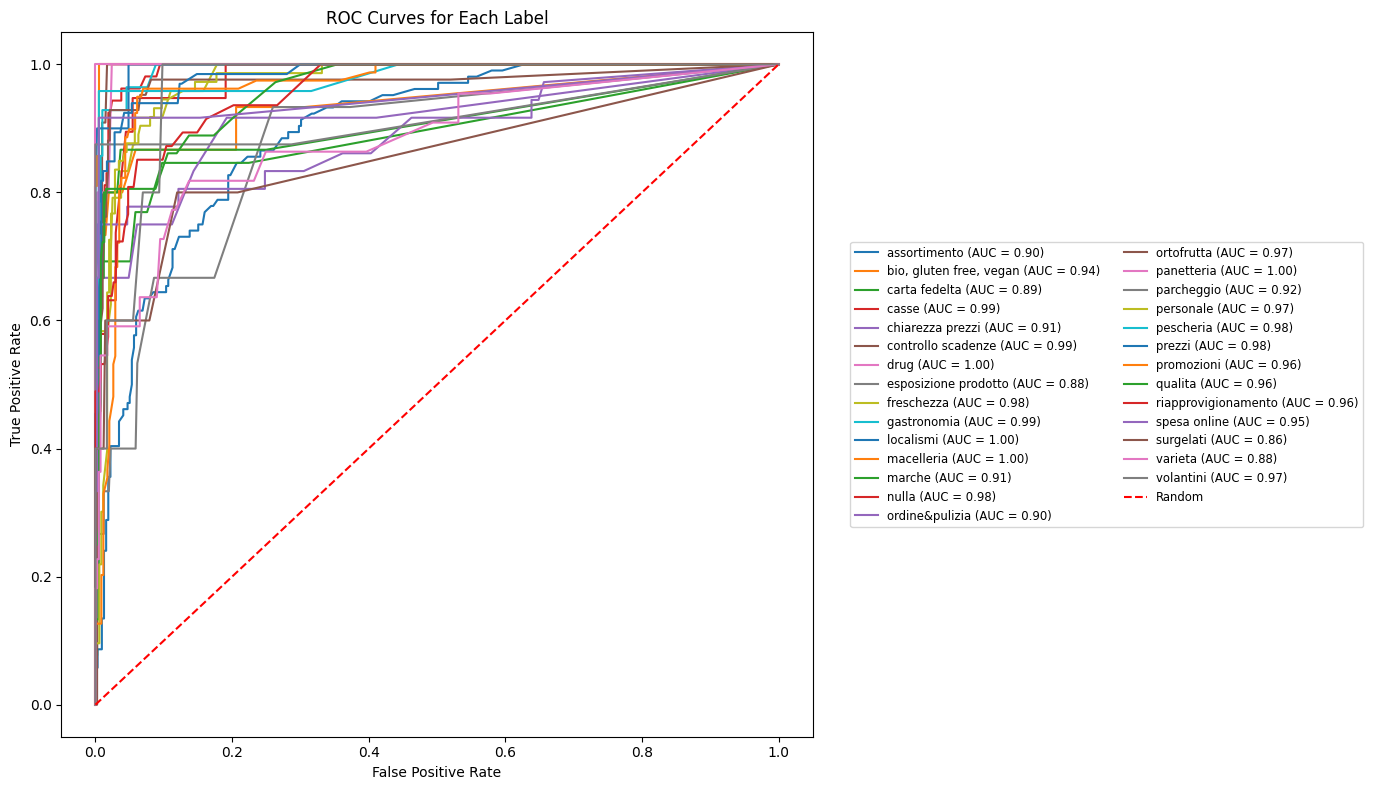

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

### with weights

In [ ]:
rf = RandomForestClassifier(random_state=193, n_jobs = -1, class_weight='balanced')
multi_rf = OneVsRestClassifier(estimator=rf)

multi_rf = multi_rf.fit(X_train, y_train)
y_pred = multi_rf.predict(X_test)
print(classification_report(y_test, y_pred,  target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.78      0.62      0.69       104
bio, gluten free, vegan       0.50      0.40      0.44        15
          carta fedelta       0.57      0.31      0.40        13
                  casse       0.88      0.79      0.83        53
       chiarezza prezzi       1.00      0.08      0.15        12
     controllo scadenze       0.50      0.09      0.15        11
                   drug       1.00      0.20      0.33         5
   esposizione prodotto       1.00      0.07      0.12        15
             freschezza       1.00      0.25      0.40        24
            gastronomia       0.92      0.82      0.87        28
              localismi       0.88      0.70      0.78        10
             macelleria       0.94      0.81      0.87        21
                 marche       0.50      0.13      0.21        15
                  nulla       0.47      0.79      0.59        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

hamming loss:  0.03554542384329618


In [ ]:
y_pred_proba = multi_rf.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

Macro AUC-ROC for the multi-label model: 0.94900158574673
Macro AUC-ROC for the multi-label model: 0.9646636235815528


AUC for Label 'assortimento': 0.91
AUC for Label 'bio, gluten free, vegan': 0.94
AUC for Label 'carta fedelta': 0.92
AUC for Label 'casse': 0.99
AUC for Label 'chiarezza prezzi': 0.93
AUC for Label 'controllo scadenze': 0.99
AUC for Label 'drug': 0.97
AUC for Label 'esposizione prodotto': 0.86
AUC for Label 'freschezza': 0.95
AUC for Label 'gastronomia': 0.99
AUC for Label 'localismi': 1.00
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.97
AUC for Label 'nulla': 0.98
AUC for Label 'ordine&pulizia': 0.89
AUC for Label 'ortofrutta': 0.97
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.92
AUC for Label 'personale': 0.96
AUC for Label 'pescheria': 0.97
AUC for Label 'prezzi': 0.97
AUC for Label 'promozioni': 0.97
AUC for Label 'qualita': 0.96
AUC for Label 'riapprovigionamento': 0.96
AUC for Label 'spesa online': 0.95
AUC for Label 'surgelati': 0.84
AUC for Label 'varieta': 0.89
AUC for Label 'volantini': 0.93


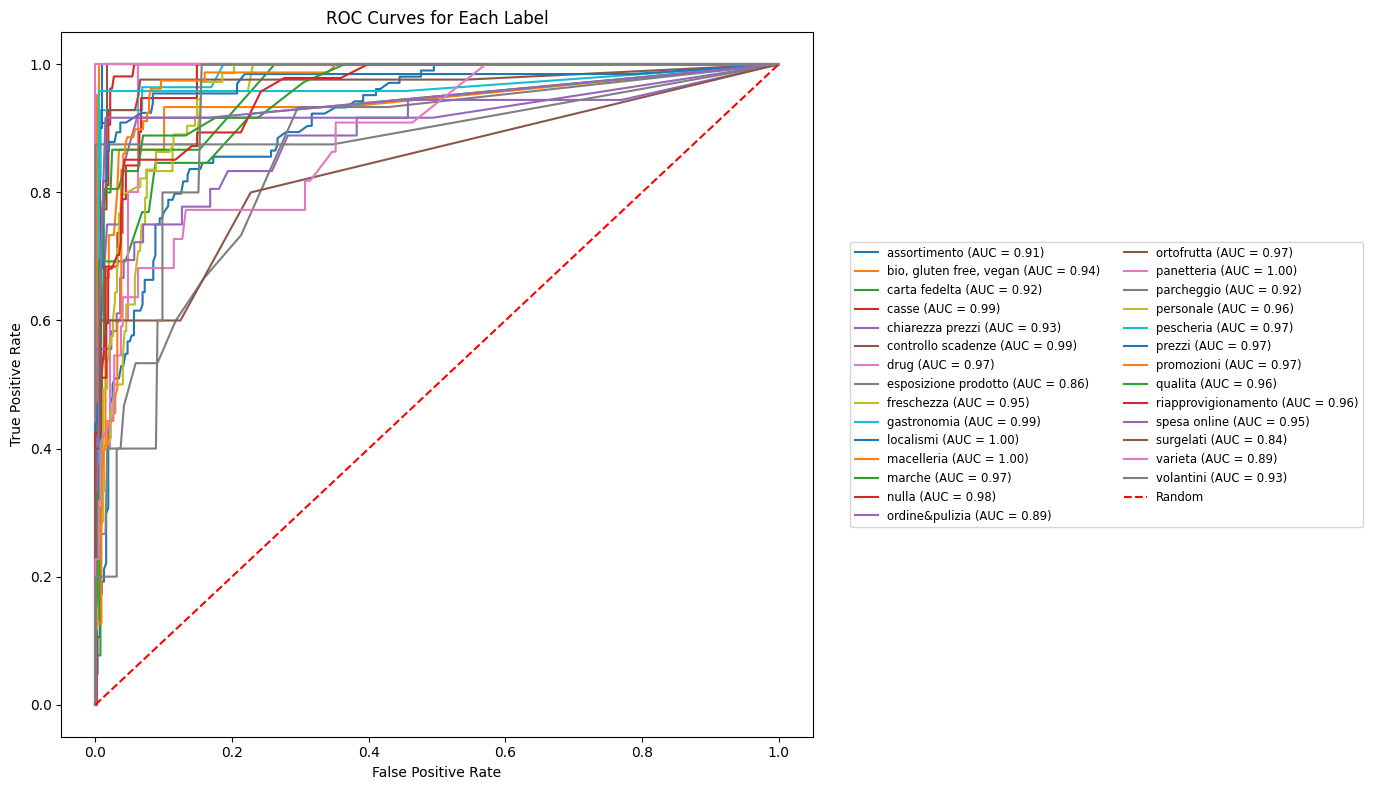

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

### stratified

In [ ]:
rf = RandomForestClassifier(random_state=193, n_jobs = -1)
multi_rf = OneVsRestClassifier(estimator=rf)

multi_rf = multi_rf.fit(X_trainS, y_trainS)
y_pred = multi_rf.predict(X_testS)
print(classification_report(y_testS, y_pred,  target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.72      0.63      0.67       100
bio, gluten free, vegan       1.00      0.23      0.38        13
          carta fedelta       0.75      0.33      0.46         9
                  casse       0.93      0.85      0.89        47
       chiarezza prezzi       0.50      0.07      0.12        14
     controllo scadenze       1.00      0.22      0.36         9
                   drug       1.00      0.17      0.29         6
   esposizione prodotto       0.67      0.14      0.24        14
             freschezza       1.00      0.55      0.71        22
            gastronomia       0.85      0.73      0.79        30
              localismi       1.00      0.44      0.62        18
             macelleria       0.92      0.85      0.88        26
                 marche       0.67      0.36      0.47        11
                  nulla       1.00      0.50      0.67        16
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_testS, y_pred))

hamming loss:  0.029747698602113876


In [ ]:
y_pred_proba = multi_rf.predict_proba(X_testS)
auc_roc_macro = roc_auc_score(y_testS, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_testS, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

Macro AUC-ROC for the multi-label model: 0.9347769571255544
Macro AUC-ROC for the multi-label model: 0.960309963966437


AUC for Label 'assortimento': 0.87
AUC for Label 'bio, gluten free, vegan': 0.80
AUC for Label 'carta fedelta': 0.99
AUC for Label 'casse': 0.99
AUC for Label 'chiarezza prezzi': 0.89
AUC for Label 'controllo scadenze': 0.93
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.79
AUC for Label 'freschezza': 0.97
AUC for Label 'gastronomia': 0.97
AUC for Label 'localismi': 0.94
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.84
AUC for Label 'nulla': 0.96
AUC for Label 'ordine&pulizia': 0.92
AUC for Label 'ortofrutta': 0.99
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 1.00
AUC for Label 'personale': 0.93
AUC for Label 'pescheria': 1.00
AUC for Label 'prezzi': 0.99
AUC for Label 'promozioni': 0.97
AUC for Label 'qualita': 0.97
AUC for Label 'riapprovigionamento': 0.97
AUC for Label 'spesa online': 1.00
AUC for Label 'surgelati': 0.75
AUC for Label 'varieta': 0.82
AUC for Label 'volantini': 0.93


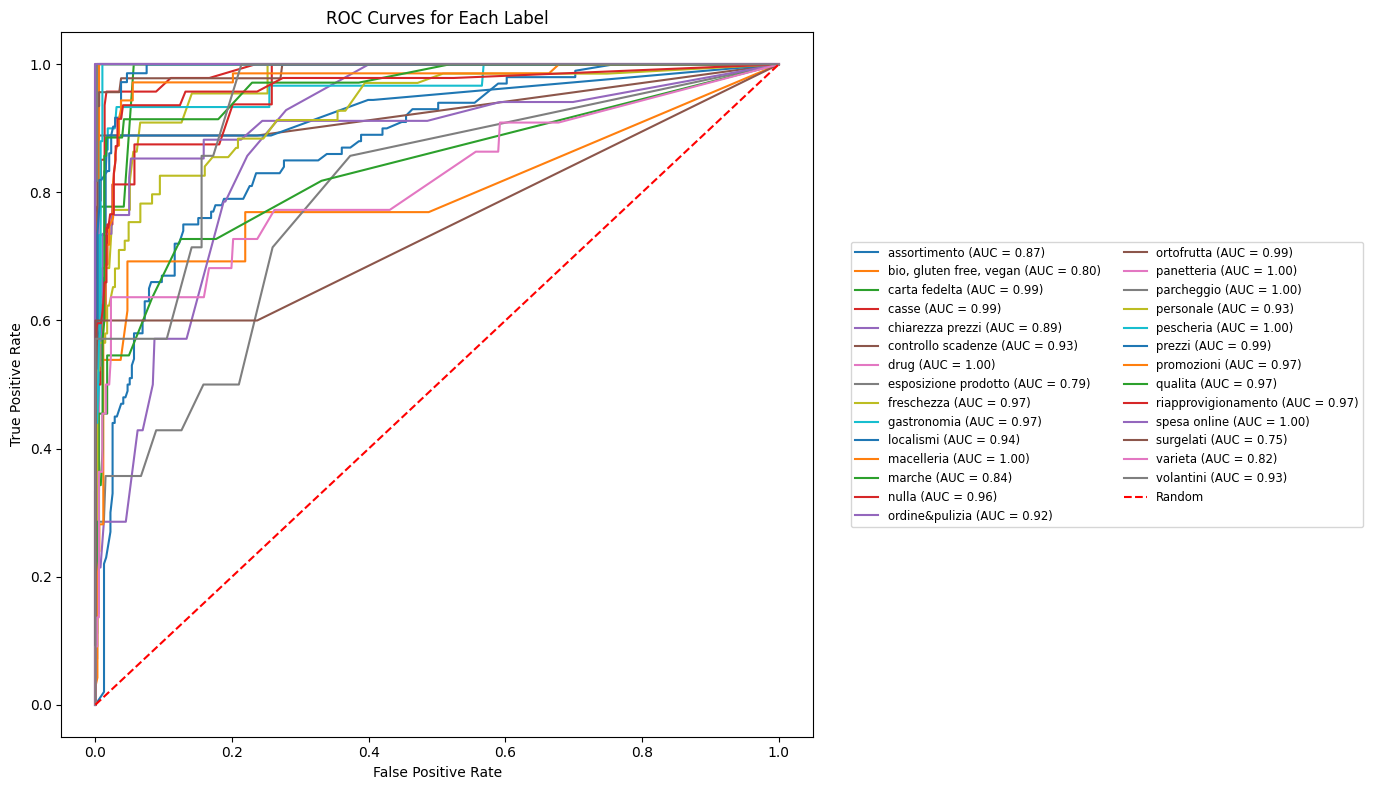

In [ ]:
draw_aucroc(y_testS, y_pred_proba, label_names)

## DecisionTree Ensemble

### without weights

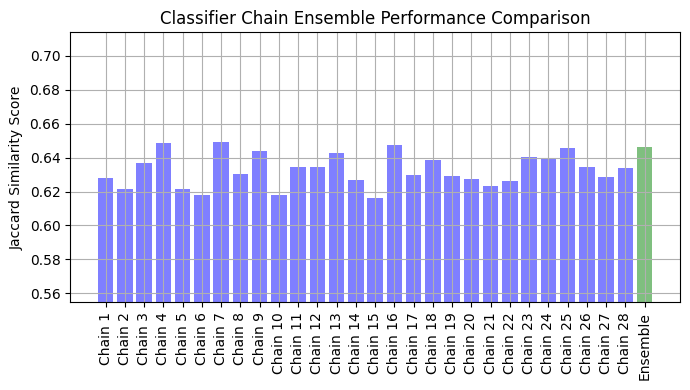

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=193)

chains = [ClassifierChain(decision_tree, order="random", random_state=i) for i in range(28)]
for chain in chains:
    chain.fit(X_train, y_train)

Y_pred_chains = np.array([chain.predict_proba(X_test) for chain in chains])
chain_jaccard_scores = [
    jaccard_score(y_test, Y_pred_chain >= 0.5, average="samples")
    for Y_pred_chain in Y_pred_chains
]

Y_pred_ensemble = Y_pred_chains.mean(axis=0)
ensemble_jaccard_score = jaccard_score(
    y_test, Y_pred_ensemble >= 0.5, average="samples"
)

model_scores = chain_jaccard_scores + [ensemble_jaccard_score]

model_names = (
    "Chain 1",
    "Chain 2",
    "Chain 3",
    "Chain 4",
    "Chain 5",
    "Chain 6",
    "Chain 7",
    "Chain 8",
    "Chain 9",
    "Chain 10",
    "Chain 11",
    "Chain 12",
    "Chain 13",
    "Chain 14",
    "Chain 15",
    "Chain 16",
    "Chain 17",
    "Chain 18",
    "Chain 19",
    "Chain 20",
    "Chain 21",
    "Chain 22",
    "Chain 23",
    "Chain 24",
    "Chain 25",
    "Chain 26",
    "Chain 27",
    "Chain 28",
    "Ensemble",
)

x_pos = np.arange(len(model_names))

fig, ax = plt.subplots(figsize=(7, 4))
ax.grid(True)
ax.set_title("Classifier Chain Ensemble Performance Comparison")
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation="vertical")
ax.set_ylabel("Jaccard Similarity Score")
ax.set_ylim([min(model_scores) * 0.9, max(model_scores) * 1.1])
colors = ["b"] * len(chain_jaccard_scores) + ["g"]
ax.bar(x_pos, model_scores, alpha=0.5, color=colors)
plt.tight_layout()
plt.show()

In [ ]:
ensemble_hamming_loss = hamming_loss(y_test, Y_pred_ensemble >= 0.5)
ensemble_jaccard_score = jaccard_score(y_test, Y_pred_ensemble >= 0.5, average="samples")
print(f"Ensemble Hamming Loss: {ensemble_hamming_loss}")
print(f"Ensemble Jaccard Score: {ensemble_jaccard_score}")

Ensemble Hamming Loss: 0.03360351232691658
Ensemble Jaccard Score: 0.6464257570640549


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

ensemble_precision_micro = precision_score(y_test, Y_pred_ensemble >= 0.5, average="micro")
ensemble_precision_macro= precision_score(y_test, Y_pred_ensemble >= 0.5, average="macro")
ensemble_recall_micro = recall_score(y_test, Y_pred_ensemble >= 0.5, average="micro")
ensemble_recall_macro = recall_score(y_test, Y_pred_ensemble >= 0.5, average="macro")

print(f"Ensemble Precision: {ensemble_precision_micro, ensemble_precision_macro}")
print(f"Ensemble Recall: {ensemble_recall_micro, ensemble_recall_macro}")

ensemble_f1_micro = f1_score(y_test, Y_pred_ensemble >= 0.5, average="micro")
print(f"Ensemble F1 Score (Micro): {ensemble_f1_micro}")

ensemble_f1_macro = f1_score(y_test, Y_pred_ensemble >= 0.5, average="macro")
print(f"Ensemble F1 Score (Macro): {ensemble_f1_macro}")

Ensemble Precision: (0.7641866330390921, 0.7385206762978745)
Ensemble Recall: (0.7417380660954712, 0.6976498302062559)
Ensemble F1 Score (Micro): 0.7527950310559006
Ensemble F1 Score (Macro): 0.7106935327503122


### with weights

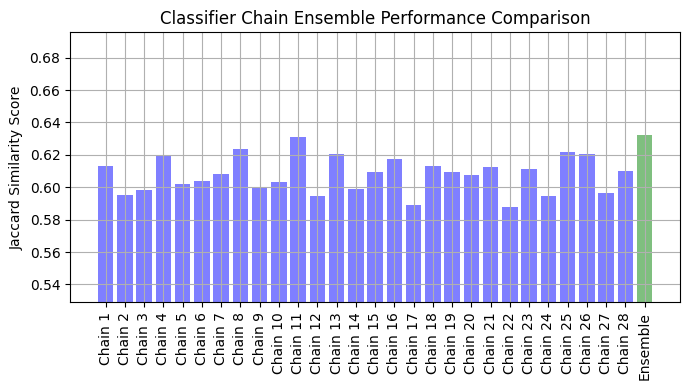

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=193, class_weight = class_weights_dict)

chains = [ClassifierChain(decision_tree, order="random", random_state=i) for i in range(28)]
for chain in chains:
    chain.fit(X_train, y_train)

Y_pred_chains = np.array([chain.predict_proba(X_test) for chain in chains])
chain_jaccard_scores = [
    jaccard_score(y_test, Y_pred_chain >= 0.5, average="samples")
    for Y_pred_chain in Y_pred_chains
]

Y_pred_ensemble = Y_pred_chains.mean(axis=0)
ensemble_jaccard_score = jaccard_score(
    y_test, Y_pred_ensemble >= 0.5, average="samples"
)

model_scores = chain_jaccard_scores + [ensemble_jaccard_score]

model_names = (
    "Chain 1",
    "Chain 2",
    "Chain 3",
    "Chain 4",
    "Chain 5",
    "Chain 6",
    "Chain 7",
    "Chain 8",
    "Chain 9",
    "Chain 10",
    "Chain 11",
    "Chain 12",
    "Chain 13",
    "Chain 14",
    "Chain 15",
    "Chain 16",
    "Chain 17",
    "Chain 18",
    "Chain 19",
    "Chain 20",
    "Chain 21",
    "Chain 22",
    "Chain 23",
    "Chain 24",
    "Chain 25",
    "Chain 26",
    "Chain 27",
    "Chain 28",
    "Ensemble",
)

x_pos = np.arange(len(model_names))

fig, ax = plt.subplots(figsize=(7, 4))
ax.grid(True)
ax.set_title("Classifier Chain Ensemble Performance Comparison")
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation="vertical")
ax.set_ylabel("Jaccard Similarity Score")
ax.set_ylim([min(model_scores) * 0.9, max(model_scores) * 1.1])
colors = ["b"] * len(chain_jaccard_scores) + ["g"]
ax.bar(x_pos, model_scores, alpha=0.5, color=colors)
plt.tight_layout()
plt.show()

In [ ]:
ensemble_hamming_loss = hamming_loss(y_test, Y_pred_ensemble >= 0.5)
ensemble_jaccard_score = jaccard_score(y_test, Y_pred_ensemble >= 0.5, average="samples")
print(f"Ensemble Hamming Loss: {ensemble_hamming_loss}")
print(f"Ensemble Jaccard Score: {ensemble_jaccard_score}")

Ensemble Hamming Loss: 0.036980749746707196
Ensemble Jaccard Score: 0.6323867687342865


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

ensemble_precision_micro = precision_score(y_test, Y_pred_ensemble >= 0.5, average="micro")
ensemble_precision_macro= precision_score(y_test, Y_pred_ensemble >= 0.5, average="macro")
ensemble_recall_micro = recall_score(y_test, Y_pred_ensemble >= 0.5, average="micro")
ensemble_recall_macro = recall_score(y_test, Y_pred_ensemble >= 0.5, average="macro")

print(f"Ensemble Precision: {ensemble_precision_micro, ensemble_precision_macro}")
print(f"Ensemble Recall: {ensemble_recall_micro, ensemble_recall_macro}")

ensemble_f1_micro = f1_score(y_test, Y_pred_ensemble >= 0.5, average="micro")
print(f"Ensemble F1 Score (Micro): {ensemble_f1_micro}"

ensemble_f1_macro = f1_score(y_test, Y_pred_ensemble >= 0.5, average="macro")
print(f"Ensemble F1 Score (Macro): {ensemble_f1_macro}")

Ensemble Precision: (0.7641866330390921, 0.7385206762978745)
Ensemble Recall: (0.7417380660954712, 0.6976498302062559)
Ensemble F1 Score (Micro): 0.7527950310559006
Ensemble F1 Score (Macro): 0.7106935327503122


### stratified

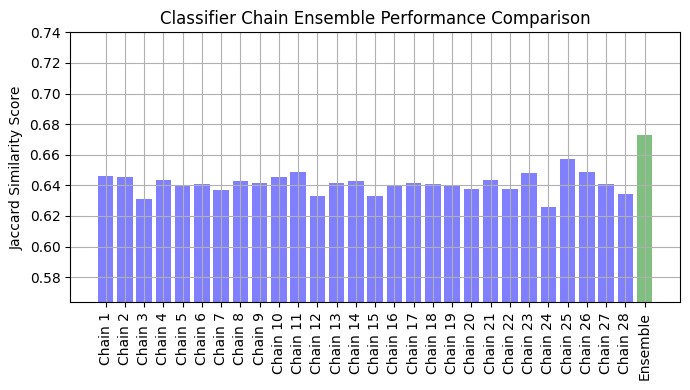

In [ ]:
decision_tree = DecisionTreeClassifier(random_state=193, class_weight = class_weights_dict)

chains = [ClassifierChain(decision_tree, order="random", random_state=i) for i in range(28)]
for chain in chains:
    chain.fit(X_trainS, y_trainS)

Y_pred_chains = np.array([chain.predict_proba(X_testS) for chain in chains])
chain_jaccard_scores = [
    jaccard_score(y_testS, Y_pred_chain >= 0.5, average="samples")
    for Y_pred_chain in Y_pred_chains
]

Y_pred_ensemble = Y_pred_chains.mean(axis=0)
ensemble_jaccard_score = jaccard_score(
    y_testS, Y_pred_ensemble >= 0.5, average="samples"
)

model_scores = chain_jaccard_scores + [ensemble_jaccard_score]

model_names = (
    "Chain 1",
    "Chain 2",
    "Chain 3",
    "Chain 4",
    "Chain 5",
    "Chain 6",
    "Chain 7",
    "Chain 8",
    "Chain 9",
    "Chain 10",
    "Chain 11",
    "Chain 12",
    "Chain 13",
    "Chain 14",
    "Chain 15",
    "Chain 16",
    "Chain 17",
    "Chain 18",
    "Chain 19",
    "Chain 20",
    "Chain 21",
    "Chain 22",
    "Chain 23",
    "Chain 24",
    "Chain 25",
    "Chain 26",
    "Chain 27",
    "Chain 28",
    "Ensemble",
)

x_pos = np.arange(len(model_names))

fig, ax = plt.subplots(figsize=(7, 4))
ax.grid(True)
ax.set_title("Classifier Chain Ensemble Performance Comparison")
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation="vertical")
ax.set_ylabel("Jaccard Similarity Score")
ax.set_ylim([min(model_scores) * 0.9, max(model_scores) * 1.1])
colors = ["b"] * len(chain_jaccard_scores) + ["g"]
ax.bar(x_pos, model_scores, alpha=0.5, color=colors)
plt.tight_layout()
plt.show()

In [ ]:
ensemble_hamming_loss = hamming_loss(y_testS, Y_pred_ensemble >= 0.5)
ensemble_jaccard_score = jaccard_score(y_testS, Y_pred_ensemble >= 0.5, average="samples")
print(f"Ensemble Hamming Loss: {ensemble_hamming_loss}")
print(f"Ensemble Jaccard Score: {ensemble_jaccard_score}")

Ensemble Hamming Loss: 0.03537333787930447
Ensemble Jaccard Score: 0.672738379361291


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

ensemble_precision_micro = precision_score(y_testS, Y_pred_ensemble >= 0.5, average="micro")
ensemble_precision_macro= precision_score(y_testS, Y_pred_ensemble >= 0.5, average="macro")
ensemble_recall_micro = recall_score(y_testS, Y_pred_ensemble >= 0.5, average="micro")
ensemble_recall_macro = recall_score(y_testS, Y_pred_ensemble >= 0.5, average="macro")

print(f"Ensemble Precision: {ensemble_precision_micro, ensemble_precision_macro}")
print(f"Ensemble Recall: {ensemble_recall_micro, ensemble_recall_macro}")

ensemble_f1_micro = f1_score(y_testS, Y_pred_ensemble >= 0.5, average="micro")
print(f"Ensemble F1 Score (Micro): {ensemble_f1_micro}")

ensemble_f1_macro = f1_score(y_testS, Y_pred_ensemble >= 0.5, average="macro")
print(f"Ensemble F1 Score (Macro): {ensemble_f1_macro}")

Ensemble Precision: (0.7253521126760564, 0.7202596252282344)
Ensemble Recall: (0.7734668335419274, 0.7344549333168063)
Ensemble F1 Score (Micro): 0.7486371895820715
Ensemble F1 Score (Macro): 0.7150328514705206


## SVM BAGGING

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, classification_report

estimator_range = [6, 8, 10, 16, 20, 28]

models = []
auroc_scores = []
macro_avg_scores = []
micro_avg_scores = []

for n_estimators in estimator_range:
    base_svc = SVC(kernel='linear', probability=True, random_state=22)
    calibrated_svc = CalibratedClassifierCV(estimator=base_svc, method='sigmoid', cv=3)
    clf = BaggingClassifier(estimator=calibrated_svc, n_estimators=n_estimators, random_state=22)
    multi_bagg = OneVsRestClassifier(estimator=clf)
    multi_bagg.fit(X_train, y_train)

    y_pred = multi_bagg.predict(X_test)
    y_prob = multi_bagg.predict_proba(X_test)
    auroc = roc_auc_score(y_true=y_test, y_score=y_prob, average='macro')
    auroc_scores.append(auroc)

    precision_macro, recall_macro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    precision_micro, recall_micro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='micro', zero_division=0)

    macro_avg_scores.append((precision_macro, recall_macro))
    micro_avg_scores.append((precision_micro, recall_micro))

    print(f"Model with {n_estimators} estimators")
    print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))
    print(f"AUROC: {auroc}")
    print(f"Macro Precision: {precision_macro}, Macro Recall: {recall_macro}")
    print(f"Micro Precision: {precision_micro}, Micro Recall: {recall_micro}\n")


print("Summary for all models:")
for i, n_estimators in enumerate(estimator_range):
    print(f"Model with {n_estimators} estimators:")
    print(f"AUROC: {auroc_scores[i]}")
    print(f"Macro Precision: {macro_avg_scores[i][0]}, Macro Recall: {macro_avg_scores[i][1]}")
    print(f"Micro Precision: {micro_avg_scores[i][0]}, Micro Recall: {micro_avg_scores[i][1]}")
    print()


Model with 6 estimators
                         precision    recall  f1-score   support

           assortimento       0.87      0.43      0.58       104
bio, gluten free, vegan       0.78      0.47      0.58        15
          carta fedelta       0.67      0.31      0.42        13
                  casse       0.86      0.81      0.83        53
       chiarezza prezzi       0.50      0.08      0.14        12
     controllo scadenze       0.75      0.27      0.40        11
                   drug       0.80      0.80      0.80         5
   esposizione prodotto       0.75      0.20      0.32        15
             freschezza       1.00      0.21      0.34        24
            gastronomia       0.88      0.82      0.85        28
              localismi       0.88      0.70      0.78        10
             macelleria       0.95      0.95      0.95        21
                 marche       0.88      0.47      0.61        15
                  nulla       1.00      0.32      0.48        19


In [ ]:
n_estimators = 20
models = []
auroc_scores = []
macro_avg_scores = []
micro_avg_scores = []
base_svc = SVC(kernel='linear', probability=True, random_state=22)
calibrated_svc = CalibratedClassifierCV(estimator=base_svc, method='sigmoid', cv=3)
clf = BaggingClassifier(estimator=calibrated_svc, n_estimators=n_estimators, random_state=22)
multi_bagg = OneVsRestClassifier(estimator=clf)
multi_bagg.fit(X_train, y_train)

y_pred = multi_bagg.predict(X_test)
y_prob = multi_bagg.predict_proba(X_test)
auroc = roc_auc_score(y_true=y_test, y_score=y_prob, average='macro')
auroc_scores.append(auroc)

precision_macro, recall_macro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
precision_micro, recall_micro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='micro', zero_division=0)

macro_avg_scores.append((precision_macro, recall_macro))
micro_avg_scores.append((precision_micro, recall_micro))

print(f"Model with {n_estimators} estimators")
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))
print(f"AUROC: {auroc}")
print(f"Macro Precision: {precision_macro}, Macro Recall: {recall_macro}")
print(f"Micro Precision: {precision_micro}, Micro Recall: {recall_micro}\n")

print("Summary for the model:")
print(f"Model with {n_estimators} estimators:")
print(f"AUROC: {auroc_scores[0]}")
print(f"Macro Precision: {macro_avg_scores[0][0]}, Macro Recall: {macro_avg_scores[0][1]}")
print(f"Micro Precision: {micro_avg_scores[0][0]}, Micro Recall: {micro_avg_scores[0][1]}")


Model with 20 estimators
                         precision    recall  f1-score   support

           assortimento       0.85      0.43      0.57       104
bio, gluten free, vegan       0.78      0.47      0.58        15
          carta fedelta       0.67      0.31      0.42        13
                  casse       0.86      0.81      0.83        53
       chiarezza prezzi       0.67      0.17      0.27        12
     controllo scadenze       0.80      0.36      0.50        11
                   drug       0.80      0.80      0.80         5
   esposizione prodotto       0.75      0.20      0.32        15
             freschezza       0.88      0.29      0.44        24
            gastronomia       0.88      0.79      0.83        28
              localismi       0.88      0.70      0.78        10
             macelleria       0.95      0.95      0.95        21
                 marche       0.75      0.40      0.52        15
                  nulla       0.70      0.37      0.48        19

AUC for Label 'assortimento': 0.91
AUC for Label 'bio, gluten free, vegan': 0.94
AUC for Label 'carta fedelta': 0.91
AUC for Label 'casse': 0.99
AUC for Label 'chiarezza prezzi': 0.92
AUC for Label 'controllo scadenze': 0.99
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.91
AUC for Label 'freschezza': 0.96
AUC for Label 'gastronomia': 0.99
AUC for Label 'localismi': 0.99
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.99
AUC for Label 'nulla': 0.96
AUC for Label 'ordine&pulizia': 0.90
AUC for Label 'ortofrutta': 0.98
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.95
AUC for Label 'personale': 0.96
AUC for Label 'pescheria': 1.00
AUC for Label 'prezzi': 0.98
AUC for Label 'promozioni': 0.96
AUC for Label 'qualita': 0.94
AUC for Label 'riapprovigionamento': 0.94
AUC for Label 'spesa online': 0.95
AUC for Label 'surgelati': 0.89
AUC for Label 'varieta': 0.86
AUC for Label 'volantini': 0.99


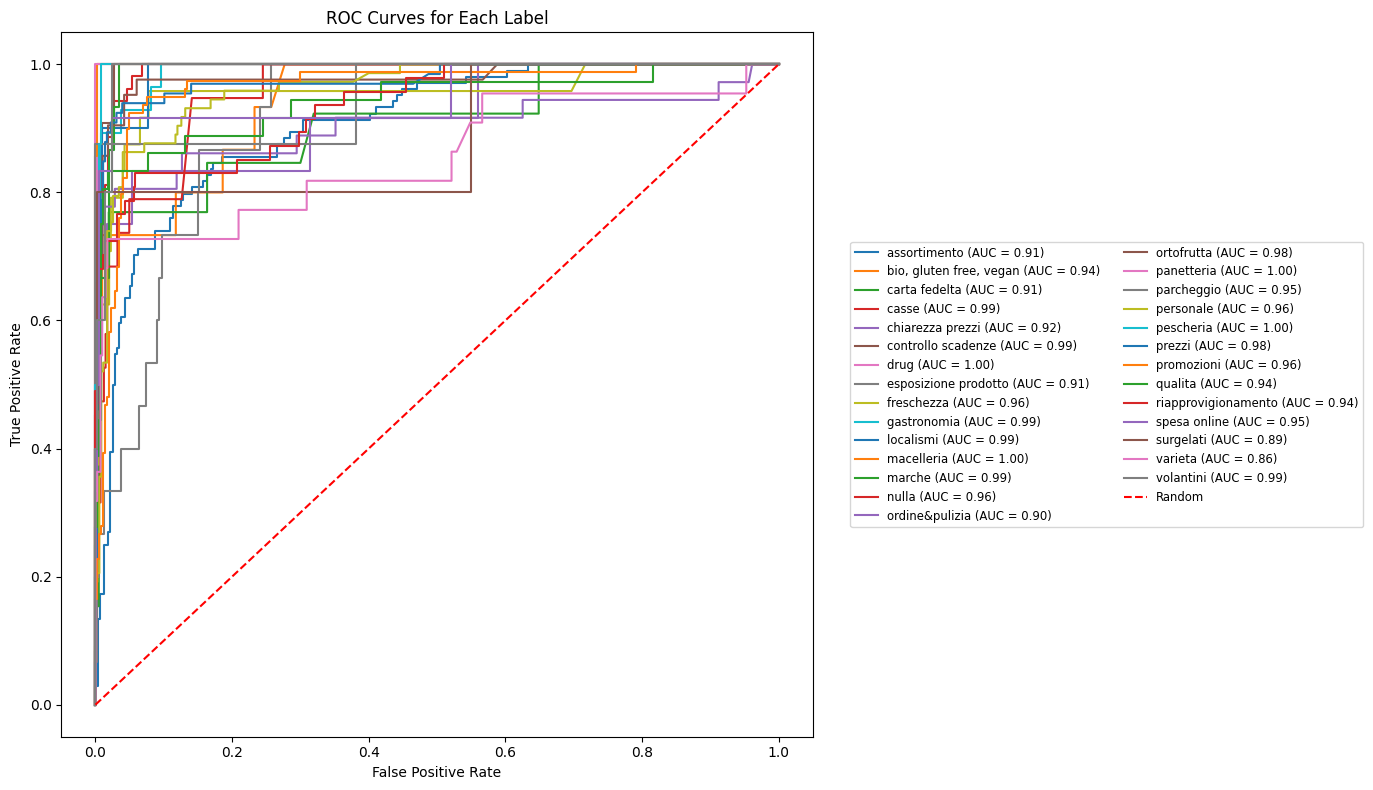

In [ ]:
draw_aucroc(y_test, y_prob, label_names)

## Bagging

In [ ]:
estimator_range = [6, 8, 10, 16, 20, 28]

models = []
auroc_scores = []
macro_avg_scores = []
micro_avg_scores = []

for n_estimators in estimator_range:

    clf = BaggingClassifier(n_estimators=n_estimators, random_state=22)
    multi_bagg = OneVsRestClassifier(estimator=clf)
    multi_bagg.fit(X_train, y_train)


    y_pred = multi_bagg.predict(X_test)
    y_prob = multi_bagg.predict_proba(X_test)
    auroc = roc_auc_score(y_true=y_test, y_score=y_prob, average='macro')
    auroc_scores.append(auroc)

    precision_macro, recall_macro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    precision_micro, recall_micro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='micro', zero_division=0)

    macro_avg_scores.append((precision_macro, recall_macro))
    micro_avg_scores.append((precision_micro, recall_micro))


    print(f"Model with {n_estimators} estimators")
    print(classification_report(y_test, y_pred,  target_names=label_names, zero_division=0))
    print(f"AUROC: {auroc}")
    print(f"Macro Precision: {precision_macro}, Macro Recall: {recall_macro}")
    print(f"Micro Precision: {precision_micro}, Micro Recall: {recall_micro}\n")


print("Summary for all models:")
for i, n_estimators in enumerate(estimator_range):
    print(f"Model with {n_estimators} estimators:")
    print(f"AUROC: {auroc_scores[i]}")
    print(f"Macro Precision: {macro_avg_scores[i][0]}, Macro Recall: {macro_avg_scores[i][1]}")
    print(f"Micro Precision: {micro_avg_scores[i][0]}, Micro Recall: {micro_avg_scores[i][1]}")
    print()

Model with 6 estimators
                         precision    recall  f1-score   support

           assortimento       0.71      0.57      0.63       104
bio, gluten free, vegan       0.80      0.53      0.64        15
          carta fedelta       0.88      0.54      0.67        13
                  casse       0.87      0.85      0.86        53
       chiarezza prezzi       0.75      0.50      0.60        12
     controllo scadenze       0.57      0.36      0.44        11
                   drug       0.80      0.80      0.80         5
   esposizione prodotto       0.50      0.27      0.35        15
             freschezza       0.68      0.62      0.65        24
            gastronomia       0.79      0.93      0.85        28
              localismi       0.86      0.60      0.71        10
             macelleria       0.86      0.90      0.88        21
                 marche       0.80      0.53      0.64        15
                  nulla       0.69      0.47      0.56        19


In [ ]:
estimator_range = 28

models = []
auroc_scores = []
macro_avg_scores = []
micro_avg_scores = []


clf = BaggingClassifier(n_estimators=n_estimators, random_state=22)
multi_bagg = OneVsRestClassifier(estimator=clf)
multi_bagg.fit(X_train, y_train)
y_pred = multi_bagg.predict(X_test)
y_prob = multi_bagg.predict_proba(X_test)
auroc = roc_auc_score(y_true=y_test, y_score=y_prob, average='macro')
auroc_scores.append(auroc)
precision_macro, recall_macro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
precision_micro, recall_micro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='micro', zero_division=0)
macro_avg_scores.append((precision_macro, recall_macro))
micro_avg_scores.append((precision_micro, recall_micro))


print(f"Model with {n_estimators} estimators")
print(classification_report(y_test, y_pred,  target_names=label_names, zero_division=0))
print(f"AUROC: {auroc}")
print(f"Macro Precision: {precision_macro}, Macro Recall: {recall_macro}")
print(f"Micro Precision: {precision_micro}, Micro Recall: {recall_micro}\n")


print("Summary for all models:")
for i, n_estimators in enumerate(estimator_range):
    print(f"Model with {n_estimators} estimators:")
    print(f"AUROC: {auroc_scores[i]}")
    print(f"Macro Precision: {macro_avg_scores[i][0]}, Macro Recall: {macro_avg_scores[i][1]}")
    print(f"Micro Precision: {micro_avg_scores[i][0]}, Micro Recall: {micro_avg_scores[i][1]}")
    print()

Model with 20 estimators
                         precision    recall  f1-score   support

           assortimento       0.69      0.58      0.63       104
bio, gluten free, vegan       0.83      0.67      0.74        15
          carta fedelta       0.89      0.62      0.73        13
                  casse       0.87      0.91      0.89        53
       chiarezza prezzi       0.78      0.58      0.67        12
     controllo scadenze       0.62      0.45      0.53        11
                   drug       0.60      0.60      0.60         5
   esposizione prodotto       0.44      0.27      0.33        15
             freschezza       0.73      0.67      0.70        24
            gastronomia       0.84      0.93      0.88        28
              localismi       0.82      0.90      0.86        10
             macelleria       0.87      0.95      0.91        21
                 marche       0.80      0.53      0.64        15
                  nulla       0.69      0.47      0.56        19

TypeError: 'int' object is not iterable

AUC for Label 'assortimento': 0.87
AUC for Label 'bio, gluten free, vegan': 0.89
AUC for Label 'carta fedelta': 0.92
AUC for Label 'casse': 0.98
AUC for Label 'chiarezza prezzi': 0.90
AUC for Label 'controllo scadenze': 0.99
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.77
AUC for Label 'freschezza': 0.95
AUC for Label 'gastronomia': 0.97
AUC for Label 'localismi': 1.00
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.93
AUC for Label 'nulla': 0.96
AUC for Label 'ordine&pulizia': 0.88
AUC for Label 'ortofrutta': 0.96
AUC for Label 'panetteria': 1.00
AUC for Label 'parcheggio': 0.94
AUC for Label 'personale': 0.95
AUC for Label 'pescheria': 0.98
AUC for Label 'prezzi': 0.95
AUC for Label 'promozioni': 0.95
AUC for Label 'qualita': 0.92
AUC for Label 'riapprovigionamento': 0.93
AUC for Label 'spesa online': 0.96
AUC for Label 'surgelati': 0.79
AUC for Label 'varieta': 0.85
AUC for Label 'volantini': 1.00


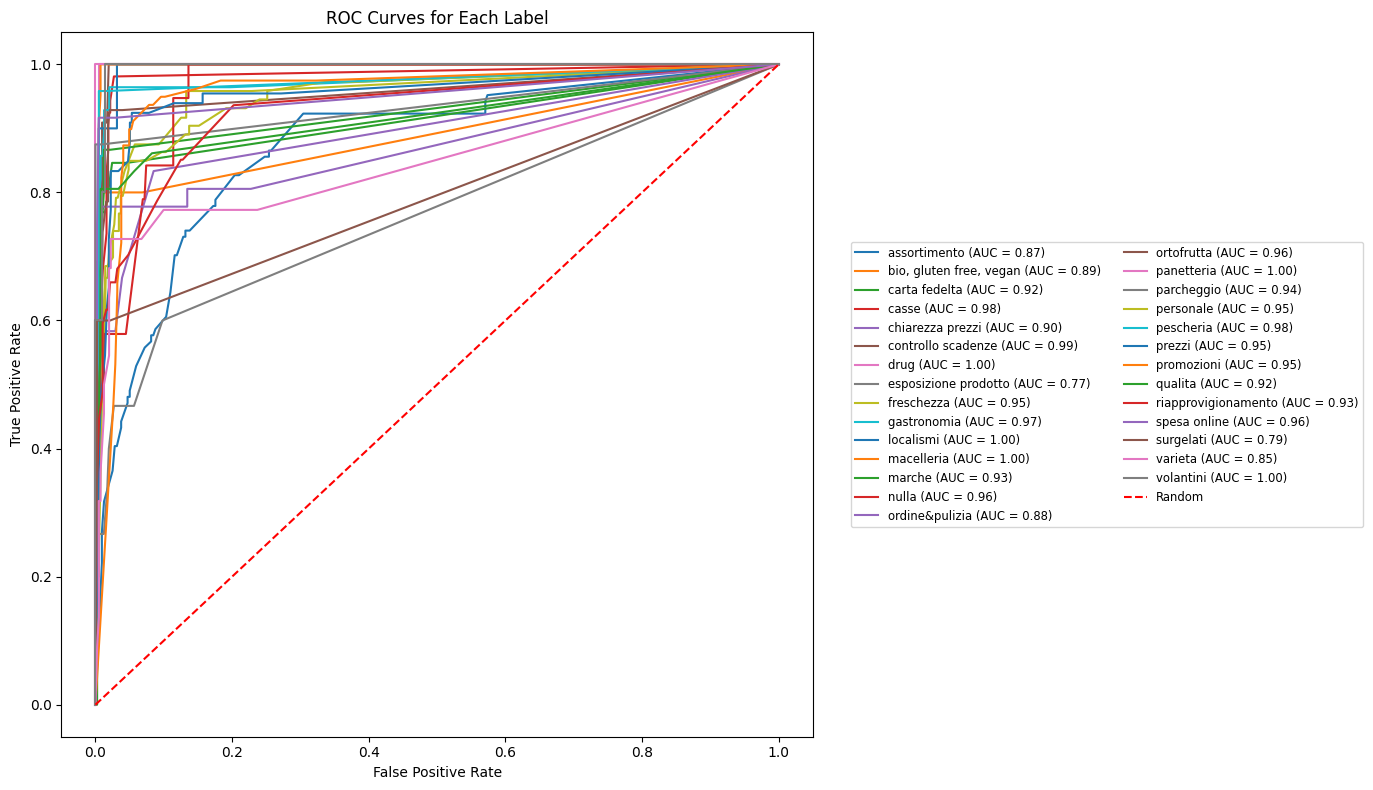

In [ ]:
draw_aucroc(y_test, y_prob, label_names)

In [ ]:
estimator_range = [6, 8, 10, 16, 20, 28]

models = []
auroc_scores = []
macro_avg_scores = []
micro_avg_scores = []

for n_estimators in estimator_range:
    clf = BaggingClassifier(DecisionTreeClassifier(class_weight='balanced'),
                            n_estimators=n_estimators, random_state=22)
    multi_bagg = OneVsRestClassifier(estimator=clf)
    multi_bagg.fit(X_train, y_train)

    y_pred = multi_bagg.predict(X_test)
    y_prob = multi_bagg.predict_proba(X_test)
    auroc = roc_auc_score(y_true=y_test, y_score=y_prob, average='macro')
    auroc_scores.append(auroc)

    precision_macro, recall_macro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    precision_micro, recall_micro, _, _ = precision_recall_fscore_support(y_test, y_pred, average='micro', zero_division=0)

    macro_avg_scores.append((precision_macro, recall_macro))
    micro_avg_scores.append((precision_micro, recall_micro))

    print(f"Model with {n_estimators} estimators")
    print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))
    print(f"AUROC: {auroc}")
    print(f"Macro Precision: {precision_macro}, Macro Recall: {recall_macro}")
    print(f"Micro Precision: {precision_micro}, Micro Recall: {recall_micro}\n")

print("Summary for all models:")
for i, n_estimators in enumerate(estimator_range):
    print(f"Model with {n_estimators} estimators:")
    print(f"AUROC: {auroc_scores[i]}")
    print(f"Macro Precision: {macro_avg_scores[i][0]}, Macro Recall: {macro_avg_scores[i][1]}")
    print(f"Micro Precision: {micro_avg_scores[i][0]}, Micro Recall: {micro_avg_scores[i][1]}")
    print()

Model with 6 estimators
                         precision    recall  f1-score   support

           assortimento       0.69      0.59      0.64       104
bio, gluten free, vegan       0.60      0.60      0.60        15
          carta fedelta       0.55      0.46      0.50        13
                  casse       0.88      0.83      0.85        53
       chiarezza prezzi       0.25      0.42      0.31        12
     controllo scadenze       0.75      0.55      0.63        11
                   drug       0.44      0.80      0.57         5
   esposizione prodotto       0.56      0.33      0.42        15
             freschezza       0.64      0.75      0.69        24
            gastronomia       0.87      0.93      0.90        28
              localismi       0.75      0.90      0.82        10
             macelleria       0.88      1.00      0.93        21
                 marche       0.82      0.60      0.69        15
                  nulla       0.32      0.84      0.46        19


## Boosting

In [ ]:
from xgboost import XGBClassifier

### without weights

In [ ]:
multi_xgb = OneVsRestClassifier(XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
multi_xgb.fit(X_train, y_train)

y_pred = multi_xgb.predict(X_test)
print(classification_report(y_test, y_pred,  target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.71      0.53      0.60       104
bio, gluten free, vegan       0.70      0.47      0.56        15
          carta fedelta       0.75      0.46      0.57        13
                  casse       0.87      0.89      0.88        53
       chiarezza prezzi       0.67      0.33      0.44        12
     controllo scadenze       0.90      0.82      0.86        11
                   drug       1.00      0.40      0.57         5
   esposizione prodotto       0.67      0.13      0.22        15
             freschezza       0.80      0.50      0.62        24
            gastronomia       0.89      0.86      0.87        28
              localismi       0.89      0.80      0.84        10
             macelleria       0.95      1.00      0.98        21
                 marche       0.50      0.13      0.21        15
                  nulla       0.75      0.47      0.58        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

hamming loss:  0.03183046268152651


In [ ]:
y_pred_proba = multi_xgb.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

Macro AUC-ROC for the multi-label model: 0.9193745928098701
Macro AUC-ROC for the multi-label model: 0.9488402173856336


AUC for Label 'assortimento': 0.89
AUC for Label 'bio, gluten free, vegan': 0.89
AUC for Label 'carta fedelta': 0.82
AUC for Label 'casse': 0.96
AUC for Label 'chiarezza prezzi': 0.92
AUC for Label 'controllo scadenze': 1.00
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.77
AUC for Label 'freschezza': 0.93
AUC for Label 'gastronomia': 0.97
AUC for Label 'localismi': 0.96
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.85
AUC for Label 'nulla': 0.96
AUC for Label 'ordine&pulizia': 0.90
AUC for Label 'ortofrutta': 0.95
AUC for Label 'panetteria': 0.98
AUC for Label 'parcheggio': 0.93
AUC for Label 'personale': 0.94
AUC for Label 'pescheria': 0.99
AUC for Label 'prezzi': 0.95
AUC for Label 'promozioni': 0.95
AUC for Label 'qualita': 0.94
AUC for Label 'riapprovigionamento': 0.93
AUC for Label 'spesa online': 0.85
AUC for Label 'surgelati': 0.73
AUC for Label 'varieta': 0.81
AUC for Label 'volantini': 0.99


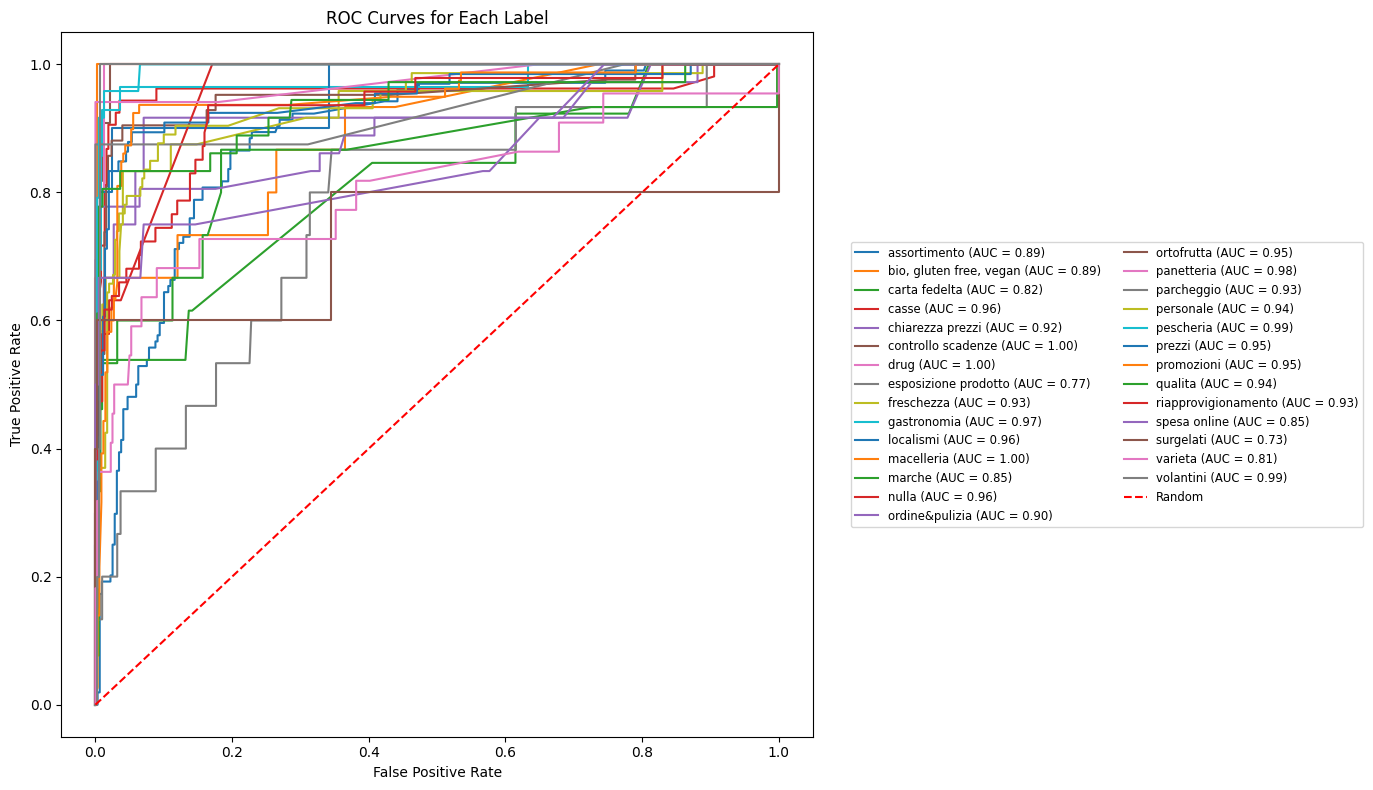

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

### stratified

In [ ]:
multi_xgb = OneVsRestClassifier(XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
multi_xgb.fit(X_trainS, y_trainS)

y_pred = multi_xgb.predict(X_testS)
print(classification_report(y_testS, y_pred,  target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.68      0.65      0.67       100
bio, gluten free, vegan       1.00      0.23      0.38        13
          carta fedelta       0.88      0.78      0.82         9
                  casse       0.91      0.91      0.91        47
       chiarezza prezzi       0.56      0.36      0.43        14
     controllo scadenze       0.60      0.67      0.63         9
                   drug       0.75      0.50      0.60         6
   esposizione prodotto       0.50      0.14      0.22        14
             freschezza       0.81      0.59      0.68        22
            gastronomia       0.79      0.73      0.76        30
              localismi       0.81      0.72      0.76        18
             macelleria       0.86      0.92      0.89        26
                 marche       0.71      0.45      0.56        11
                  nulla       1.00      0.56      0.72        16
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_testS, y_pred))

hamming loss:  0.03034435731333106


In [ ]:
y_pred_proba = multi_xgb.predict_proba(X_testS)
auc_roc_macro = roc_auc_score(y_testS, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_testS, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

Macro AUC-ROC for the multi-label model: 0.930050312433088
Macro AUC-ROC for the multi-label model: 0.9554464575276856


AUC for Label 'assortimento': 0.87
AUC for Label 'bio, gluten free, vegan': 0.80
AUC for Label 'carta fedelta': 0.98
AUC for Label 'casse': 0.98
AUC for Label 'chiarezza prezzi': 0.94
AUC for Label 'controllo scadenze': 0.93
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.73
AUC for Label 'freschezza': 0.95
AUC for Label 'gastronomia': 0.97
AUC for Label 'localismi': 0.95
AUC for Label 'macelleria': 0.97
AUC for Label 'marche': 0.86
AUC for Label 'nulla': 0.92
AUC for Label 'ordine&pulizia': 0.92
AUC for Label 'ortofrutta': 0.98
AUC for Label 'panetteria': 0.96
AUC for Label 'parcheggio': 1.00
AUC for Label 'personale': 0.90
AUC for Label 'pescheria': 1.00
AUC for Label 'prezzi': 0.98
AUC for Label 'promozioni': 0.98
AUC for Label 'qualita': 0.95
AUC for Label 'riapprovigionamento': 0.94
AUC for Label 'spesa online': 0.86
AUC for Label 'surgelati': 0.93
AUC for Label 'varieta': 0.89
AUC for Label 'volantini': 0.92


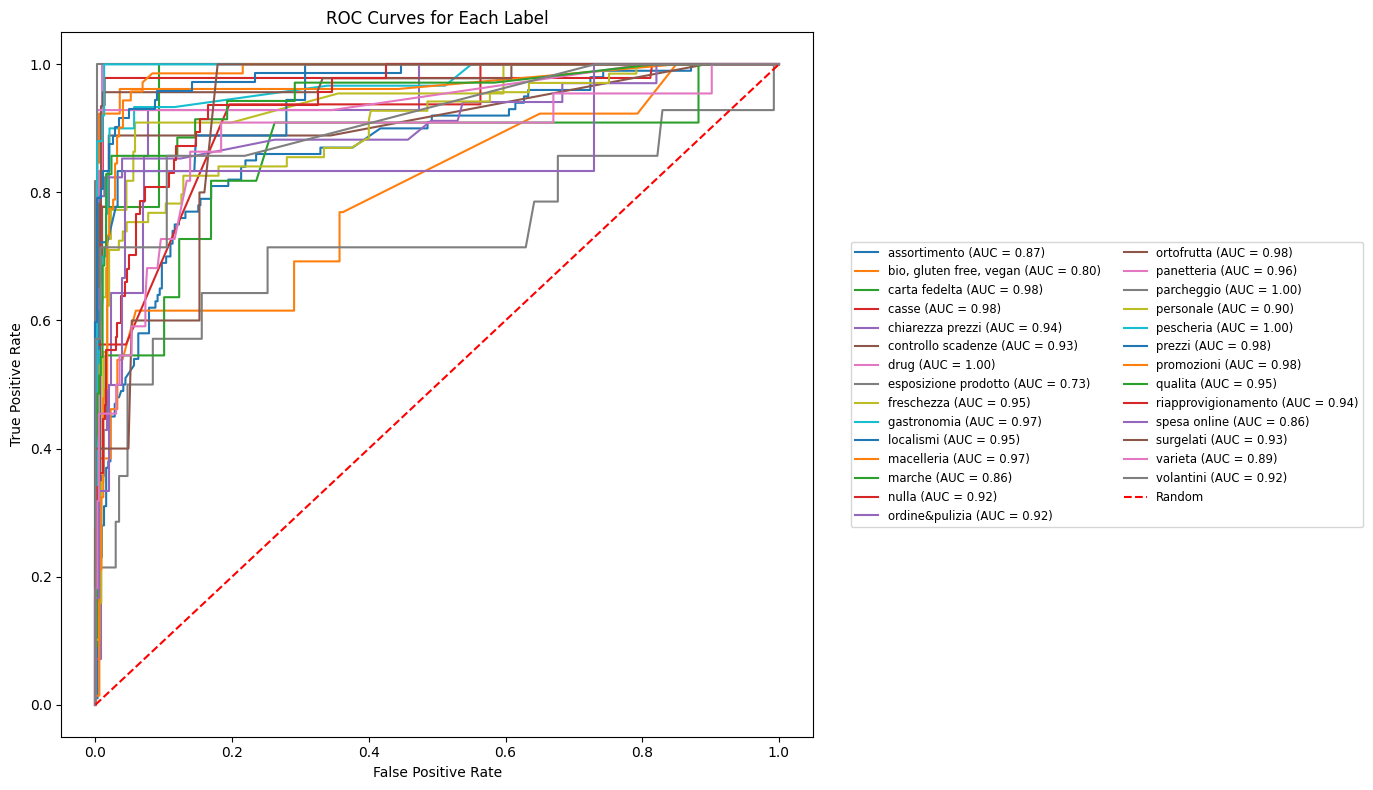

In [ ]:
draw_aucroc(y_testS, y_pred_proba, label_names)

### LGBMClassifier

In [ ]:
lgb_clf = LGBMClassifier(random_state=65, verbose=-1)
multi_output_lgb_clf = OneVsRestClassifier(lgb_clf)
multi_output_lgb_clf.fit(X_train, y_train)
y_pred = multi_output_lgb_clf.predict(X_test)
print(classification_report(y_test, y_pred,  target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.71      0.55      0.62       104
bio, gluten free, vegan       0.55      0.40      0.46        15
          carta fedelta       0.67      0.31      0.42        13
                  casse       0.90      0.85      0.87        53
       chiarezza prezzi       0.75      0.25      0.38        12
     controllo scadenze       0.50      0.36      0.42        11
                   drug       0.00      0.00      0.00         5
   esposizione prodotto       0.67      0.13      0.22        15
             freschezza       0.75      0.38      0.50        24
            gastronomia       0.88      0.82      0.85        28
              localismi       0.60      0.60      0.60        10
             macelleria       0.95      1.00      0.98        21
                 marche       0.75      0.40      0.52        15
                  nulla       0.75      0.47      0.58        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

hamming loss:  0.038331644714623435


In [ ]:
y_pred_proba = multi_output_lgb_clf.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

Macro AUC-ROC for the multi-label model: 0.8799262746440919
Macro AUC-ROC for the multi-label model: 0.9199481322078145


AUC for Label 'assortimento': 0.88
AUC for Label 'bio, gluten free, vegan': 0.87
AUC for Label 'carta fedelta': 0.81
AUC for Label 'casse': 0.94
AUC for Label 'chiarezza prezzi': 0.87
AUC for Label 'controllo scadenze': 0.98
AUC for Label 'drug': 0.65
AUC for Label 'esposizione prodotto': 0.68
AUC for Label 'freschezza': 0.95
AUC for Label 'gastronomia': 0.97
AUC for Label 'localismi': 0.92
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.79
AUC for Label 'nulla': 0.97
AUC for Label 'ordine&pulizia': 0.85
AUC for Label 'ortofrutta': 0.96
AUC for Label 'panetteria': 0.78
AUC for Label 'parcheggio': 0.96
AUC for Label 'personale': 0.89
AUC for Label 'pescheria': 0.99
AUC for Label 'prezzi': 0.92
AUC for Label 'promozioni': 0.94
AUC for Label 'qualita': 0.93
AUC for Label 'riapprovigionamento': 0.92
AUC for Label 'spesa online': 0.57
AUC for Label 'surgelati': 0.87
AUC for Label 'varieta': 0.84
AUC for Label 'volantini': 0.95


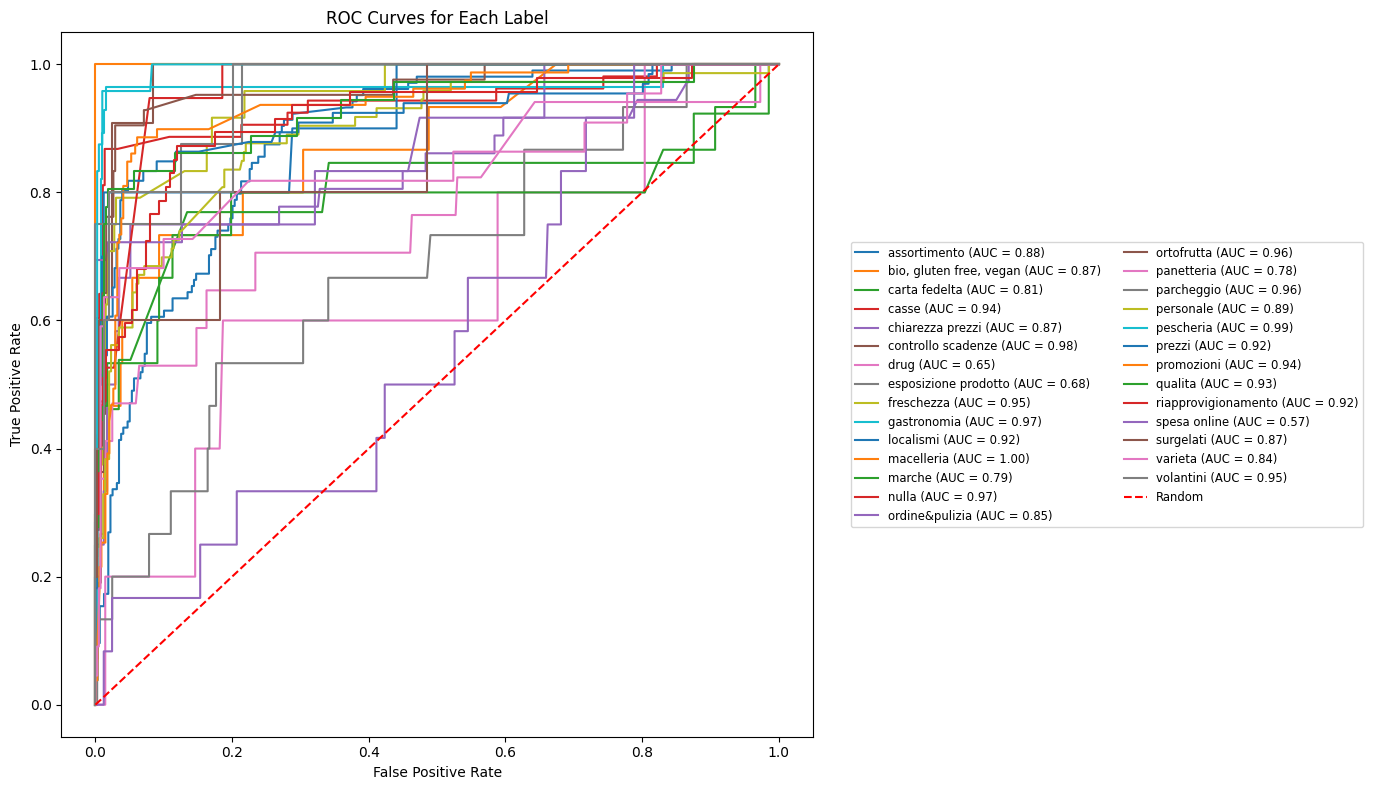

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

In [ ]:
lgb_clf = LGBMClassifier(random_state=65, verbose=-1)
multi_output_lgb_clf = OneVsRestClassifier(lgb_clf)
multi_output_lgb_clf.fit(X_trainS, y_trainS)
y_pred = multi_output_lgb_clf.predict(X_testS)
print(classification_report(y_testS, y_pred,  target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.65      0.62      0.64       100
bio, gluten free, vegan       0.50      0.08      0.13        13
          carta fedelta       0.80      0.44      0.57         9
                  casse       0.93      0.83      0.88        47
       chiarezza prezzi       0.67      0.29      0.40        14
     controllo scadenze       0.43      0.33      0.38         9
                   drug       0.50      0.17      0.25         6
   esposizione prodotto       0.40      0.14      0.21        14
             freschezza       0.76      0.59      0.67        22
            gastronomia       0.83      0.80      0.81        30
              localismi       0.82      0.78      0.80        18
             macelleria       0.83      0.92      0.87        26
                 marche       0.56      0.45      0.50        11
                  nulla       0.75      0.38      0.50        16
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_testS, y_pred))

hamming loss:  0.03341288782816229


In [ ]:
y_pred_proba = multi_output_lgb_clf.predict_proba(X_testS)
auc_roc_macro = roc_auc_score(y_testS, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_testS, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

Macro AUC-ROC for the multi-label model: 0.901635332401244
Macro AUC-ROC for the multi-label model: 0.9381463521068765


AUC for Label 'assortimento': 0.86
AUC for Label 'bio, gluten free, vegan': 0.72
AUC for Label 'carta fedelta': 0.88
AUC for Label 'casse': 0.98
AUC for Label 'chiarezza prezzi': 0.96
AUC for Label 'controllo scadenze': 0.85
AUC for Label 'drug': 0.77
AUC for Label 'esposizione prodotto': 0.78
AUC for Label 'freschezza': 0.95
AUC for Label 'gastronomia': 0.94
AUC for Label 'localismi': 0.98
AUC for Label 'macelleria': 0.96
AUC for Label 'marche': 0.91
AUC for Label 'nulla': 0.94
AUC for Label 'ordine&pulizia': 0.91
AUC for Label 'ortofrutta': 0.95
AUC for Label 'panetteria': 0.96
AUC for Label 'parcheggio': 0.97
AUC for Label 'personale': 0.90
AUC for Label 'pescheria': 0.99
AUC for Label 'prezzi': 0.97
AUC for Label 'promozioni': 0.95
AUC for Label 'qualita': 0.93
AUC for Label 'riapprovigionamento': 0.95
AUC for Label 'spesa online': 0.76
AUC for Label 'surgelati': 0.85
AUC for Label 'varieta': 0.85
AUC for Label 'volantini': 0.85


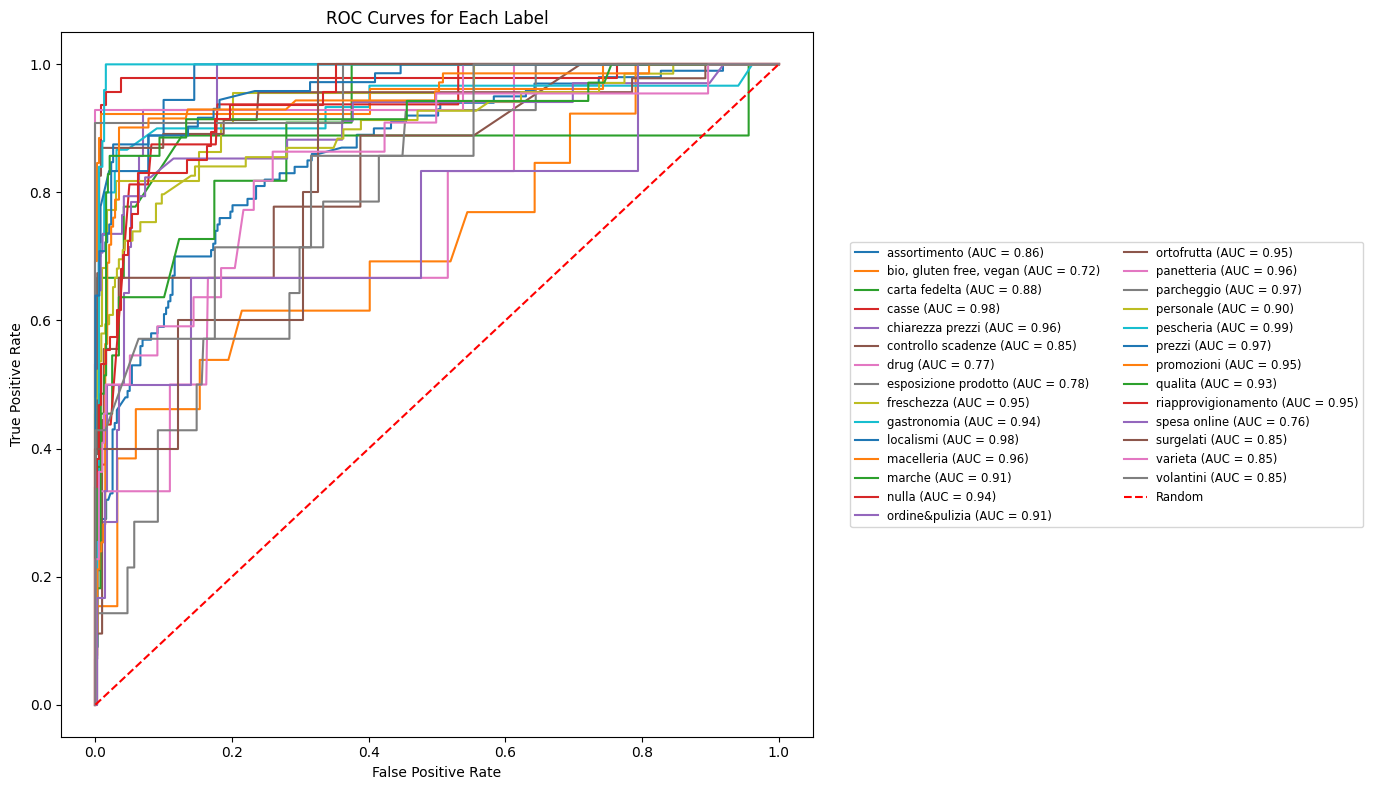

In [ ]:
draw_aucroc(y_testS, y_pred_proba, label_names)

## BORN

In [ ]:
born_benchmark = BornClassifier()
multi_output_born = OneVsRestClassifier(born_benchmark)
multi_output_born.fit(X_train, y_train)
y_pred = multi_output_born.predict(X_test)

print(classification_report(y_test, y_pred,  target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.62      0.88      0.73       104
bio, gluten free, vegan       0.27      0.67      0.38        15
          carta fedelta       0.24      0.69      0.35        13
                  casse       0.60      0.94      0.73        53
       chiarezza prezzi       0.14      0.58      0.23        12
     controllo scadenze       0.32      1.00      0.49        11
                   drug       0.12      1.00      0.22         5
   esposizione prodotto       0.24      0.53      0.33        15
             freschezza       0.24      0.71      0.35        24
            gastronomia       0.38      0.93      0.54        28
              localismi       0.22      1.00      0.36        10
             macelleria       0.40      1.00      0.57        21
                 marche       0.28      0.67      0.39        15
                  nulla       0.48      0.74      0.58        19
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_test, y_pred))

hamming loss:  0.08983451536643026


In [ ]:
y_pred_proba = multi_output_born.predict_proba(X_test)
auc_roc_macro = roc_auc_score(y_test, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_test, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

Macro AUC-ROC for the multi-label model: 0.9379600960628877
Macro AUC-ROC for the multi-label model: 0.9479391798854908


AUC for Label 'assortimento': 0.90
AUC for Label 'bio, gluten free, vegan': 0.90
AUC for Label 'carta fedelta': 0.87
AUC for Label 'casse': 0.98
AUC for Label 'chiarezza prezzi': 0.89
AUC for Label 'controllo scadenze': 0.99
AUC for Label 'drug': 1.00
AUC for Label 'esposizione prodotto': 0.88
AUC for Label 'freschezza': 0.89
AUC for Label 'gastronomia': 0.98
AUC for Label 'localismi': 0.99
AUC for Label 'macelleria': 1.00
AUC for Label 'marche': 0.96
AUC for Label 'nulla': 0.82
AUC for Label 'ordine&pulizia': 0.94
AUC for Label 'ortofrutta': 0.97
AUC for Label 'panetteria': 0.99
AUC for Label 'parcheggio': 0.99
AUC for Label 'personale': 0.95
AUC for Label 'pescheria': 0.99
AUC for Label 'prezzi': 0.96
AUC for Label 'promozioni': 0.95
AUC for Label 'qualita': 0.91
AUC for Label 'riapprovigionamento': 0.91
AUC for Label 'spesa online': 0.95
AUC for Label 'surgelati': 0.91
AUC for Label 'varieta': 0.83
AUC for Label 'volantini': 0.96


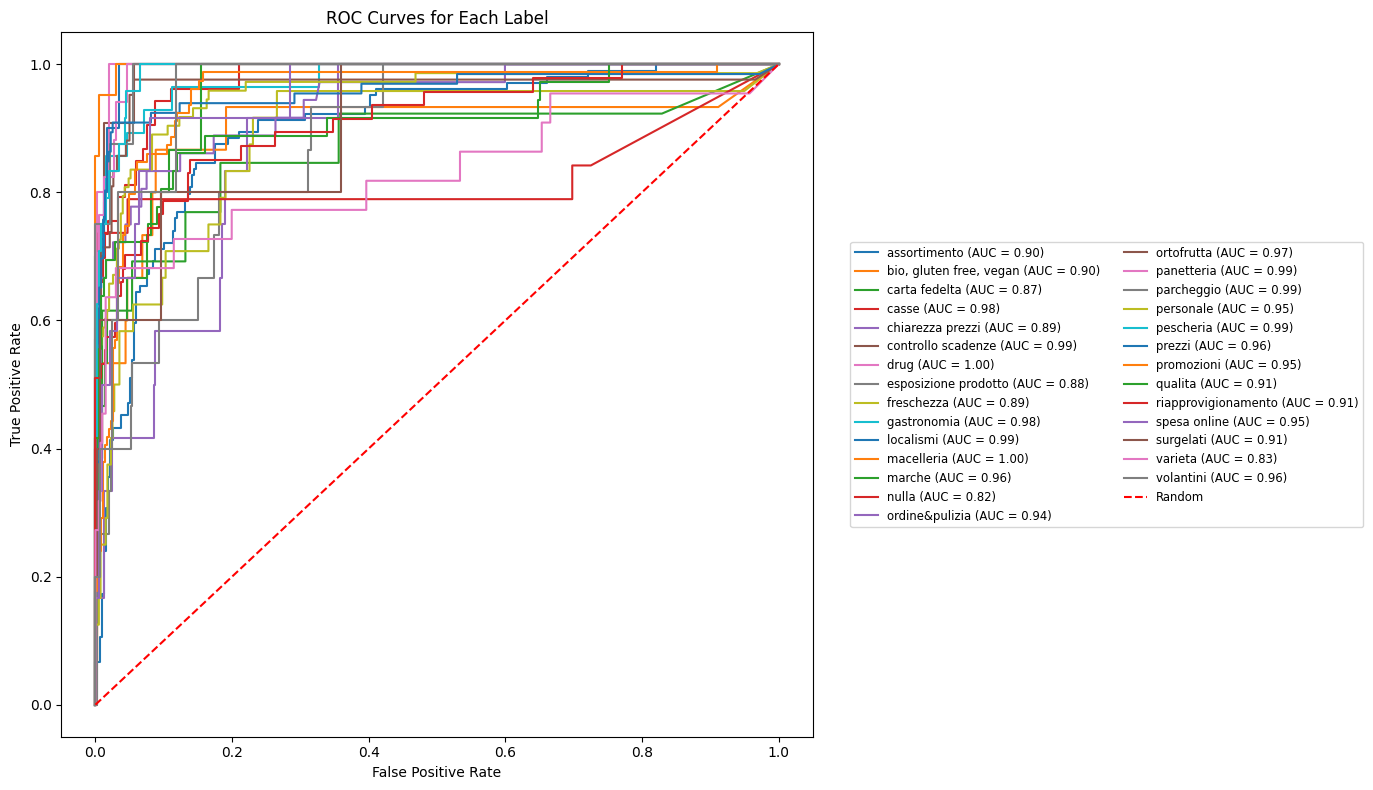

In [ ]:
draw_aucroc(y_test, y_pred_proba, label_names)

In [ ]:
multi_output_born.fit(X_trainS, y_trainS)
y_pred = multi_output_born.predict(X_testS)

print(classification_report(y_testS, y_pred,  target_names=label_names, zero_division=0))

                         precision    recall  f1-score   support

           assortimento       0.51      0.77      0.62       100
bio, gluten free, vegan       0.20      0.62      0.30        13
          carta fedelta       0.25      0.89      0.39         9
                  casse       0.61      0.94      0.74        47
       chiarezza prezzi       0.08      0.36      0.14        14
     controllo scadenze       0.29      0.89      0.43         9
                   drug       0.12      0.83      0.21         6
   esposizione prodotto       0.16      0.43      0.24        14
             freschezza       0.26      0.82      0.39        22
            gastronomia       0.45      0.97      0.61        30
              localismi       0.30      0.94      0.45        18
             macelleria       0.43      1.00      0.60        26
                 marche       0.12      0.55      0.19        11
                  nulla       0.50      0.75      0.60        16
         ordine&pulizia 

In [ ]:
print("hamming loss: ", hamming_loss(y_testS, y_pred))

hamming loss:  0.0961472894647119


In [ ]:
y_pred_proba = multi_output_born.predict_proba(X_testS)
auc_roc_macro = roc_auc_score(y_testS, y_pred_proba, average="macro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_macro}")

auc_roc_micro = roc_auc_score(y_testS, y_pred_proba, average="micro")
print(f"Macro AUC-ROC for the multi-label model: {auc_roc_micro}")

Macro AUC-ROC for the multi-label model: 0.9243036400377249
Macro AUC-ROC for the multi-label model: 0.9467654104812028


AUC for Label 'assortimento': 0.84
AUC for Label 'bio, gluten free, vegan': 0.90
AUC for Label 'carta fedelta': 0.95
AUC for Label 'casse': 0.98
AUC for Label 'chiarezza prezzi': 0.80
AUC for Label 'controllo scadenze': 0.92
AUC for Label 'drug': 0.98
AUC for Label 'esposizione prodotto': 0.77
AUC for Label 'freschezza': 0.92
AUC for Label 'gastronomia': 0.98
AUC for Label 'localismi': 0.96
AUC for Label 'macelleria': 0.99
AUC for Label 'marche': 0.85
AUC for Label 'nulla': 0.90
AUC for Label 'ordine&pulizia': 0.92
AUC for Label 'ortofrutta': 0.99
AUC for Label 'panetteria': 0.99
AUC for Label 'parcheggio': 1.00
AUC for Label 'personale': 0.90
AUC for Label 'pescheria': 0.97
AUC for Label 'prezzi': 0.99
AUC for Label 'promozioni': 0.98
AUC for Label 'qualita': 0.94
AUC for Label 'riapprovigionamento': 0.96
AUC for Label 'spesa online': 1.00
AUC for Label 'surgelati': 0.80
AUC for Label 'varieta': 0.86
AUC for Label 'volantini': 0.85


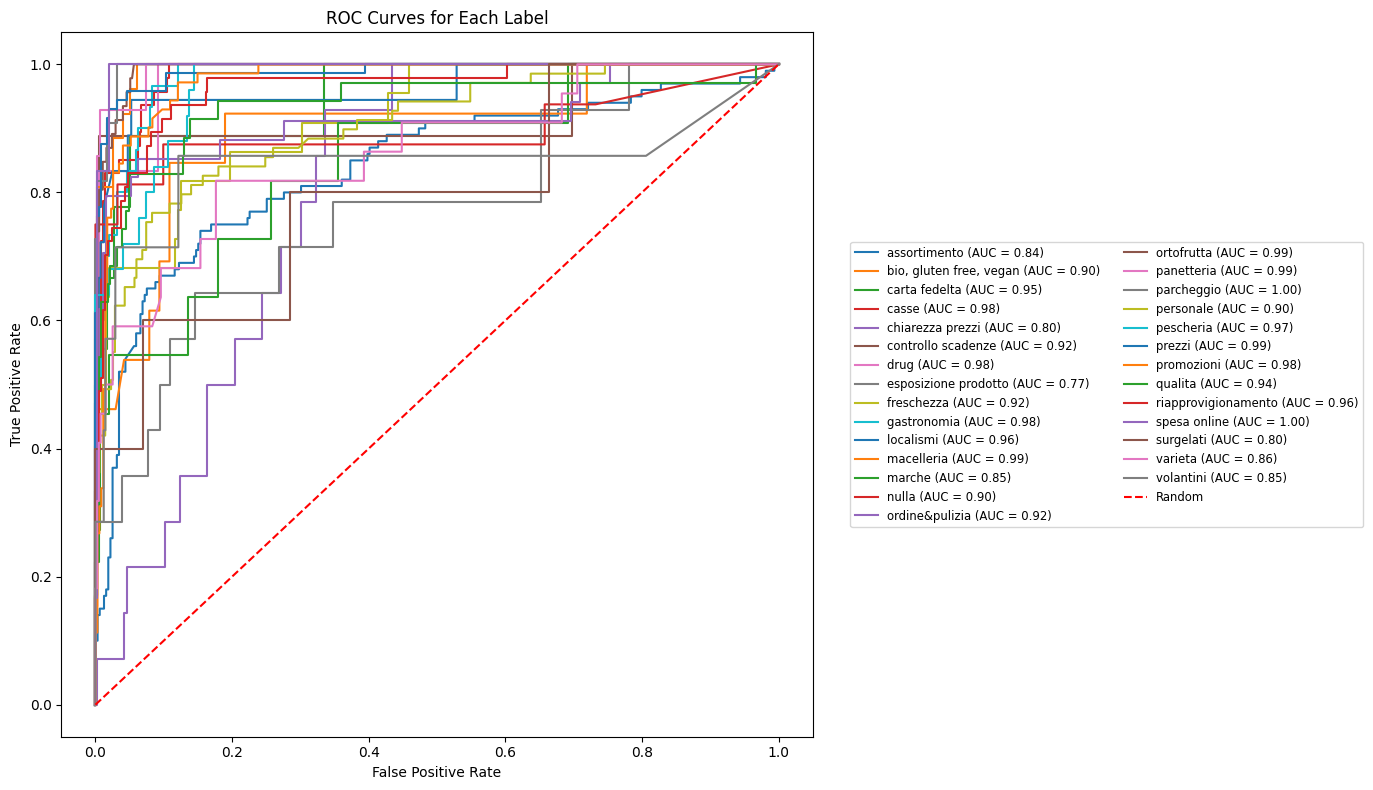

In [ ]:
draw_aucroc(y_testS, y_pred_proba, label_names)